# CO₂ → Methanol Photoelectrocatalysis on Gr/CuO and Gr/AgO Heterostructures
## Comprehensive Thermodynamic & Electronic Analysis using MACE-MP

**Framework:** MACE-MP-0 universal potential + Computational Hydrogen Electrode (CHE)  
**Systems:** Graphene/CuO and Graphene/AgO bilayer heterostructures  
**Reaction:** CO₂ + 6(H⁺ + e⁻) → CH₃OH + H₂O  

### Reaction pathway (CHE basis):
```
CO₂(g) + * → *CO₂                       [physisorption / activation]
*CO₂  + H⁺+e⁻ → *COOH                   [Step 1]
*COOH + H⁺+e⁻ → *CO + H₂O              [Step 2]
*CO   + H⁺+e⁻ → *CHO                   [Step 3, PDS on many metals]
*CHO  + H⁺+e⁻ → *CH₂O                  [Step 4]
*CH₂O + H⁺+e⁻ → *CH₃O                  [Step 5]
*CH₃O + H⁺+e⁻ → CH₃OH(g) + *          [Step 6, desorption]
```

### References
- Peterson et al., *Energy Environ. Sci.* **3**, 1311 (2010) — CHE framework  
- Batatia et al., *NeurIPS* (2022) — MACE architecture  
- Batatia et al., *Science* **381**, eadi1680 (2023) — MACE-MP-0  
- Hammer & Nørskov, *Adv. Catal.* **45**, 71 (2000) — d-band model  
- ZPE/TS corrections: Peterson et al. 2010, Nie et al. *J. Catal.* **311**, 469 (2014)

---
## 0 · Environment, Paths & Global Settings

In [19]:
# ─── Installation (run once, then restart kernel) ───────────────────────────
# !pip install mace-torch ase pymatgen matplotlib seaborn scipy pandas
# !pip install phonopy  # optional – for vibrational entropy corrections

import os, sys, warnings, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize

# ASE
from ase import Atoms
from ase.io import read, write
from ase.build import add_adsorbate, molecule
from ase.constraints import FixAtoms
from ase.optimize import FIRE, BFGS
from ase.vibrations import Vibrations
from ase.thermochemistry import HarmonicThermo, IdealGasThermo

# ── NEB: relocated in ASE >= 3.23 ────────────────────────────────────────
try:
    from ase.mep import NEB, NEBTools          # ASE >= 3.23
except ImportError:
    from ase.neb import NEB, NEBTools          # ASE < 3.23

# ── Analysis: relocated in ASE >= 3.23 ───────────────────────────────────
try:
    from ase.geometry.analysis import Analysis
except ImportError:
    from ase.analysis import Analysis

from ase.dft.kpoints import monkhorst_pack
try:
    from ase.calculators.emt import EMT  # fallback for testing
except ImportError:
    pass

# pymatgen
from pymatgen.io.vasp import Poscar
from pymatgen.core import Structure
from pymatgen.analysis.local_env import CrystalNN
from pymatgen.analysis.graphs import StructureGraph
from pymatgen.electronic_structure.dos import Dos, CompleteDos

warnings.filterwarnings("ignore")

# ─── User-defined paths ──────────────────────────────────────────────────────
# !! Update these to match your filesystem !!
CONTCAR_AGO = Path("./CONTCAR_AgO_graphene")   # CONTCAR from VASP relaxation
CONTCAR_CUO = Path("./CONTCAR_CuO_graphene")   # CONTCAR from VASP relaxation
OUTDIR      = Path("./MACE_results")
OUTDIR.mkdir(exist_ok=True)

# ─── Matplotlib style ────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLORS = {"CuO": "#C0392B", "AgO": "#2980B9", "ref": "#7F8C8D"}

print("✓ Imports OK")

✓ Imports OK


In [ ]:
import torch
from mace.calculators import mace_mp

# MPS: fast but float32 only — use for screening (fmax=0.1)
# CPU: slow but float64 — use for production (fmax=0.02-0.05)
PRODUCTION = True   # set False for quick screening runs

if PRODUCTION:
    device = "cpu"
    dtype  = "float64"
else:
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    dtype  = "float32"

calc_mace = mace_mp(model="medium", dispersion=True,
                    default_dtype=dtype, device=device)
print(f"Calculator: {dtype} on {device}")

Using Materials Project MACE for MACECalculator with /Users/marco/.cache/mace/20231203mace128L1_epoch199model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Using TorchDFTD3Calculator for D3 dispersion corrections
Calculator: float64 on cpu


In [ ]:
# ─── TEST MODE — set False for production ────────────────────────────────────
TEST_MODE = False

# Full intermediate list defined here so TEST_MODE can reference it.
# Cell 18 (§7) also assigns it for clarity.
INTERMEDIATES = ["CO2", "COOH", "CO", "CHO", "CH2O", "CH3O", "CH3OH"]

if TEST_MODE:
    print("WARNING: TEST MODE — NOT for production")
    RELAX_FMAX        = 0.5
    RELAX_STEPS       = 5
    ADS_FMAX          = 0.5
    ADS_STEPS         = 5
    NEB_FMAX          = 0.5
    NEB_STEPS         = 3
    NEB_IMAGES        = 3
    BINDING_PTS       = 5
    U_SCAN_PTS        = 20
    INTERMEDIATES_RUN = ["CO2", "COOH", "CO"]
else:
    RELAX_FMAX        = 0.02
    RELAX_STEPS       = 1000
    ADS_FMAX          = 0.05
    ADS_STEPS         = 600
    NEB_FMAX          = 0.08
    NEB_STEPS         = 600
    NEB_IMAGES        = 7
    BINDING_PTS       = 60
    U_SCAN_PTS        = 400
    INTERMEDIATES_RUN = INTERMEDIATES

print(f"Mode: {'TEST' if TEST_MODE else 'PRODUCTION'}  |  "
      f"ADS_FMAX={ADS_FMAX}  ADS_STEPS={ADS_STEPS}")
print(f"INTERMEDIATES_RUN = {INTERMEDIATES_RUN}")


Mode: PRODUCTION  |  ADS_FMAX=0.05  ADS_STEPS=300
INTERMEDIATES_RUN = ['CO2', 'COOH', 'CO', 'CHO', 'CH2O', 'CH3O', 'CH3OH']


---
## 1 · MACE-MP Calculator Initialisation

In [22]:
from mace.calculators import mace_mp

# MACE-MP-0  ('medium' ~5 M params; 'large' ~30 M params — use large for production)
# dispersion=True adds a D3-BJ dispersion correction internally
# default_dtype='float64' avoids precision issues in energy differences
DEVICE = "cpu"          # change to 'cuda' if GPU available
MODEL  = "medium"       # 'small' | 'medium' | 'large'

calc_mace = mace_mp(
    model=MODEL,
    dispersion=True,       # D3 dispersion — critical for vdW-bound graphene interface
    default_dtype="float64",
    device=DEVICE,
)


print(f"✓ MACE-MP-0 ({MODEL}) loaded on {DEVICE}")

Using Materials Project MACE for MACECalculator with /Users/marco/.cache/mace/20231203mace128L1_epoch199model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Using TorchDFTD3Calculator for D3 dispersion corrections
✓ MACE-MP-0 (medium) loaded on cpu


---
## 2 · Structure Loading, Validation & Layer Analysis

In [23]:
def load_and_validate(path: Path, label: str) -> Atoms:
    """Load CONTCAR, assign calculator, report key geometry."""
    atoms = read(str(path), format="vasp")
    atoms.calc = calc_mace
    
    # Identify graphene vs oxide layers by z-coordinate clustering
    z = atoms.get_positions()[:, 2]
    z_range = z.max() - z.min()
    symbols  = np.array(atoms.get_chemical_symbols())
    
    c_mask  = symbols == "C"
    gr_z    = z[c_mask].mean() if c_mask.any() else None
    
    # Interlayer distance (graphene to nearest non-C plane)
    nonC_z  = z[~c_mask]
    if gr_z is not None and len(nonC_z):
        closest_z  = nonC_z[np.argmin(np.abs(nonC_z - gr_z))]
        interlayer = abs(closest_z - gr_z)
    else:
        interlayer = None
    
    print(f"── {label} ──────────────────────────")
    print(f"   N atoms     : {len(atoms)}")
    print(f"   Cell (Å)    : a={atoms.cell.lengths()[0]:.3f}, "
          f"b={atoms.cell.lengths()[1]:.3f}, c={atoms.cell.lengths()[2]:.3f}")
    print(f"   Composition : {atoms.get_chemical_formula()}")
    print(f"   z-span (Å)  : {z_range:.3f}")
    if interlayer:
        print(f"   Gr–oxide gap: {interlayer:.3f} Å")
    
    return atoms


slab_AgO = load_and_validate(CONTCAR_AGO, "Gr/AgO")
slab_CuO = load_and_validate(CONTCAR_CUO, "Gr/CuO")

SLABS = {"AgO": slab_AgO, "CuO": slab_CuO}

── Gr/AgO ──────────────────────────
   N atoms     : 62
   Cell (Å)    : a=12.331, b=7.398, c=40.000
   Composition : C30Ag16O16
   z-span (Å)  : 7.536
   Gr–oxide gap: 3.046 Å
── Gr/CuO ──────────────────────────
   N atoms     : 62
   Cell (Å)    : a=12.331, b=7.398, c=40.000
   Composition : C30Cu16O16
   z-span (Å)  : 6.696
   Gr–oxide gap: 3.130 Å


In [24]:
def identify_active_sites(atoms: Atoms, metal: str, n_top: int = 3):
    """
    Return the indices and positions of the topmost metal atoms,
    which serve as candidate CO2-reduction active sites.
    """
    symbols = np.array(atoms.get_chemical_symbols())
    pos     = atoms.get_positions()
    
    metal_idx  = np.where(symbols == metal)[0]
    z_metal    = pos[metal_idx, 2]
    top_idx    = metal_idx[np.argsort(z_metal)[-n_top:]]
    
    # Hollow site: centroid of top triangle
    hollow_pos = pos[top_idx].mean(axis=0)
    hollow_pos[2] = pos[top_idx, 2].max() + 1.8  # ~1.8 Å above surface
    
    return {
        "top_idx":    top_idx,
        "top_pos":    pos[top_idx],
        "hollow_pos": hollow_pos,
        "atop_pos":   pos[top_idx[-1]] + np.array([0, 0, 1.8]),
    }


sites_AgO = identify_active_sites(slab_AgO, "Ag")
sites_CuO = identify_active_sites(slab_CuO, "Cu")

print("Active site positions (hollow, Å):")
print(f"  Gr/AgO  atop: {sites_AgO['atop_pos']}")
print(f"  Gr/CuO  atop: {sites_CuO['atop_pos']}")

Active site positions (hollow, Å):
  Gr/AgO  atop: [-2.88518978  5.56327553 28.85180183]
  Gr/CuO  atop: [-2.87466898  5.53933366 28.30947308]


In [37]:
# Quick slab energy check — run before §6
for sys, slab_rel in [("AgO", slab_AgO_rel), ("CuO", slab_CuO_rel)]:
    n   = len(slab_rel)
    epa = E_slab[sys] / n
    print(f"Gr/{sys}: E = {E_slab[sys]:.3f} eV  ({n} atoms, {epa:.3f} eV/atom)")
    # Expected range for graphene/oxide heterostructure: -6.5 to -8.5 eV/atom
    if not (-8.5 < epa < -6.5):
        print(f"  *** ANOMALOUS — re-run §3 with RELAX_STEPS=1000 ***")
    else:
        print(f"  OK")

Gr/AgO: E = -408.073 eV  (62 atoms, -6.582 eV/atom)
  OK
Gr/CuO: E = -439.981 eV  (62 atoms, -7.096 eV/atom)
  OK


---
## 3 · Slab Relaxation with MACE  
Bottom two layers fixed; top metal + graphene layers free.

In [25]:
def relax_slab(atoms: Atoms, label: str,
               fmax: float = 0.02,      # eV/Å — tight for production
               steps: int  = RELAX_STEPS,
               fix_frac: float = 0.35)  -> Atoms:
    """
    Relax slab: fix bottom `fix_frac` fraction of atoms by z-coordinate.
    Returns relaxed Atoms with energy stored in .calc.
    """
    from copy import deepcopy
    atoms = deepcopy(atoms)
    atoms.calc = calc_mace
    
    z = atoms.get_positions()[:, 2]
    z_cut = z.min() + fix_frac * (z.max() - z.min())
    fixed = np.where(z < z_cut)[0].tolist()
    atoms.set_constraint(FixAtoms(indices=fixed))
    
    traj_file = str(OUTDIR / f"relax_{label}.traj")
    opt = FIRE(atoms, trajectory=traj_file, logfile=str(OUTDIR / f"relax_{label}.log"))
    
    t0 = time.time()
    opt.run(fmax=fmax, steps=steps)
    elapsed = time.time() - t0
    
    E = atoms.get_potential_energy()
    print(f"  {label}: E = {E:.4f} eV  |  "
          f"converged={opt.converged()}  |  "
          f"steps={opt.nsteps}  |  t={elapsed:.1f}s")
    
    outpath = OUTDIR / f"CONTCAR_{label}_MACE.vasp"
    write(str(outpath), atoms, format="vasp")
    return atoms


print("Relaxing Gr/AgO slab...")
slab_AgO_rel = relax_slab(slab_AgO, "AgO", fmax=RELAX_FMAX)

print("Relaxing Gr/CuO slab...")
slab_CuO_rel = relax_slab(slab_CuO, "CuO", fmax=RELAX_FMAX)

E_slab = {
    "AgO": slab_AgO_rel.get_potential_energy(),
    "CuO": slab_CuO_rel.get_potential_energy(),
}
print(f"\nSlab reference energies: {E_slab}")

Relaxing Gr/AgO slab...
  AgO: E = -408.0728 eV  |  converged=True  |  steps=37  |  t=22.9s
Relaxing Gr/CuO slab...
  CuO: E = -439.9814 eV  |  converged=True  |  steps=32  |  t=22.5s

Slab reference energies: {'AgO': -408.07277012858157, 'CuO': -439.98140614618234}


---
## 3b · Optimal In-Plane Lattice Constant — Strain Energy Minimisation


=== Gr/AgO ===
  a_super=12.3307  n_gr=30  n_ox=32
  E0_gr=-278.2601  E0_ox=-127.7359 eV
  Scanning 30 points...
  a_eq(Gr)=12.4515  a_eq(ox)=12.3473
  C2D_Gr=185.812  C2D_ox=11.813 eV/A^2
  a_opt(num)=12.3345  a_opt(analytic)=12.4453 A
  eps_Gr=-0.940%  eps_ox=-0.104%
  Current slab a=12.3307 A  deviation=-0.03%

=== Gr/CuO ===
  a_super=12.3307  n_gr=30  n_ox=32
  E0_gr=-278.2681  E0_ox=-160.5823 eV
  Scanning 30 points...
  a_eq(Gr)=12.4512  a_eq(ox)=11.9332
  C2D_Gr=185.740  C2D_ox=7.395 eV/A^2
  a_opt(num)=12.3148  a_opt(analytic)=12.4314 A
  eps_Gr=-1.095%  eps_ox=+3.198%
  Current slab a=12.3307 A  deviation=+0.13%


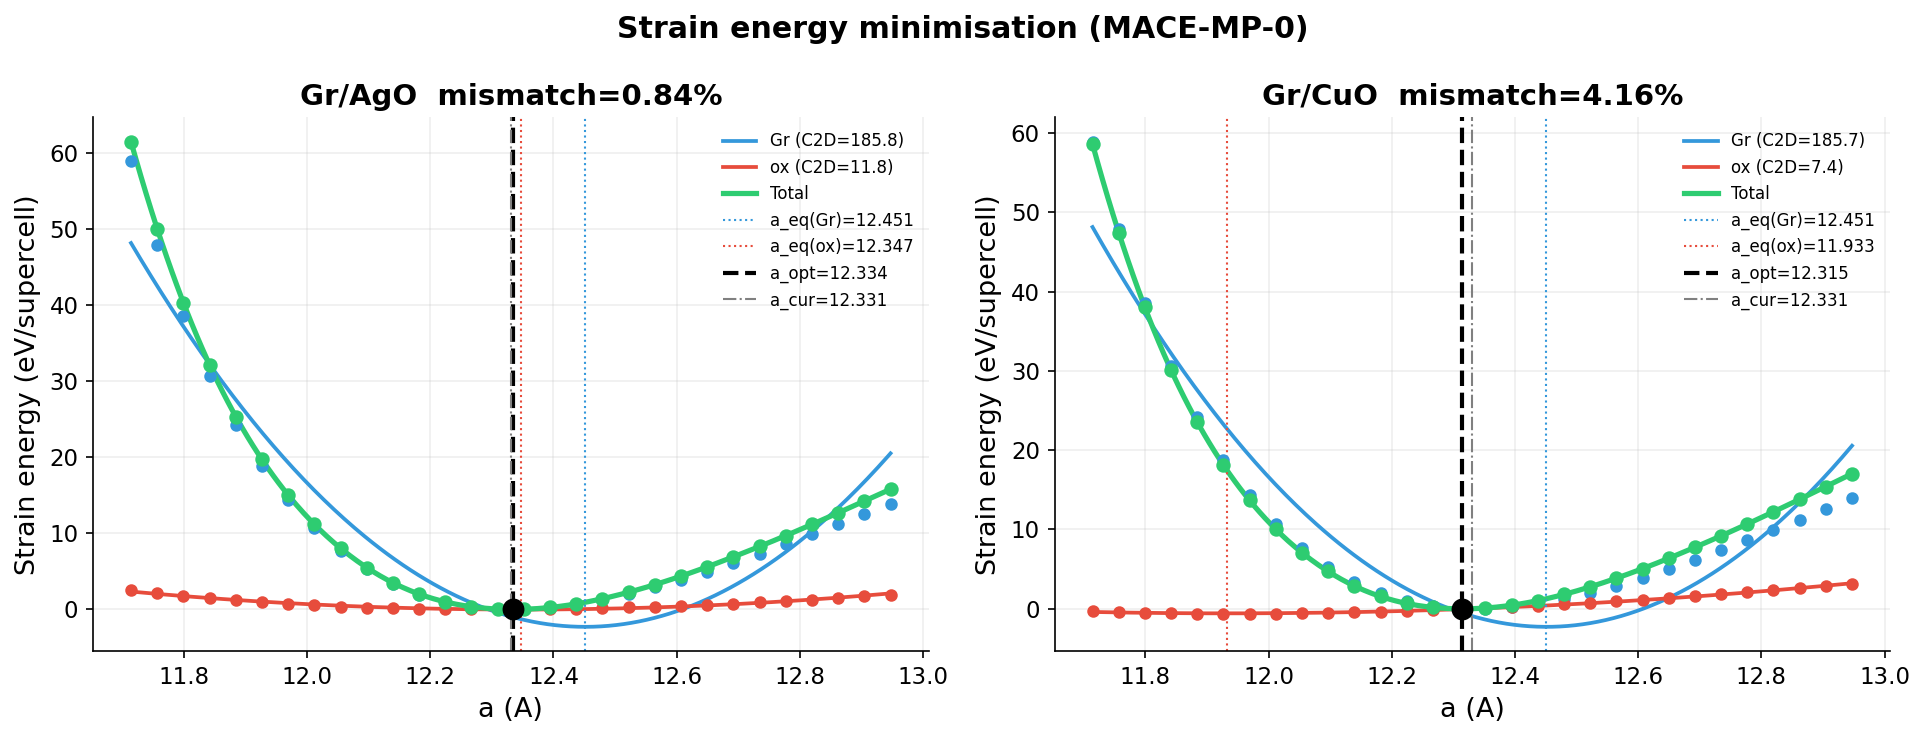

Gr/AgO: deviation 0.03% < 0.5% — keeping current slab (strain penalty < 0.01 eV)
Gr/CuO: deviation 0.13% < 0.5% — keeping current slab (strain penalty < 0.01 eV)
SLABS_RELAXED updated for §6 onwards.


In [26]:
# ═══════════════════════════════════════════════════════════════════════
# §3b · Optimal In-Plane Lattice Constant via Strain Energy Minimisation
# ═══════════════════════════════════════════════════════════════════════
# Scan E_strain(a) for each isolated layer in the supercell frame.
# Do NOT use ExpCellFilter — it collapses the supercell to the primitive
# cell size, compresses atoms, and gives catastrophic energies (~10^21 eV).
# Instead: scale in-plane cell and xy-coords at each scan point; fit
# quadratic -> a_eq per layer, C2D stiffness, and a_opt.

from copy import deepcopy
from scipy.optimize import minimize_scalar
from scipy.interpolate import UnivariateSpline

def isolate_layer(slab, layer):
    syms = np.array(slab.get_chemical_symbols())
    mask = (syms=='C') if layer=='graphene' else (syms!='C')
    sub  = slab[np.where(mask)[0]]
    sub.cell = slab.cell.array.copy()
    sub.pbc  = [True,True,False]
    return sub

def scale_inplane(atoms, a_new, a_ref):
    s   = a_new/a_ref
    tmp = deepcopy(atoms)
    c   = tmp.cell.array.copy()
    c[0,:2]*=s; c[1,:2]*=s
    tmp.set_cell(c, scale_atoms=False)
    p = tmp.get_positions()
    p[:,0]*=s; p[:,1]*=s
    tmp.set_positions(p)
    return tmp

def fit_quadratic(a_arr, E_arr):
    c2,c1,c0 = np.polyfit(a_arr,E_arr,2)
    return {'a_eq':-c1/(2*c2),'C2D':2*c2,'poly':(c2,c1,c0)}

strain_results = {}
SLABS_RELAXED  = {"AgO":slab_AgO_rel,"CuO":slab_CuO_rel}
fig,axes = plt.subplots(1,2,figsize=(13,5))

for ax,(sys_name,slab_rel) in zip(axes,SLABS_RELAXED.items()):
    print(f"\n=== Gr/{sys_name} ===")
    a_super = float(np.linalg.norm(slab_rel.cell[0,:2]))
    gr_layer = isolate_layer(slab_rel,'graphene')
    ox_layer = isolate_layer(slab_rel,'oxide')
    gr_layer.calc = calc_mace; ox_layer.calc = calc_mace
    E0_gr = gr_layer.get_potential_energy()
    E0_ox = ox_layer.get_potential_energy()
    print(f"  a_super={a_super:.4f}  n_gr={len(gr_layer)}  n_ox={len(ox_layer)}")
    print(f"  E0_gr={E0_gr:.4f}  E0_ox={E0_ox:.4f} eV")

    SCAN_FRAC=0.05; N_PTS=30
    a_lo=a_super*(1-SCAN_FRAC); a_hi=a_super*(1+SCAN_FRAC)
    a_arr=np.linspace(a_lo,a_hi,N_PTS)
    E_gr_arr=np.zeros(N_PTS); E_ox_arr=np.zeros(N_PTS)
    print(f"  Scanning {N_PTS} points...")
    for k,a in enumerate(a_arr):
        t=scale_inplane(gr_layer,a,a_super); t.calc=calc_mace
        E_gr_arr[k]=t.get_potential_energy()-E0_gr
        t=scale_inplane(ox_layer,a,a_super); t.calc=calc_mace
        E_ox_arr[k]=t.get_potential_energy()-E0_ox
    E_tot=E_gr_arr+E_ox_arr

    fit_gr=fit_quadratic(a_arr,E_gr_arr)
    fit_ox=fit_quadratic(a_arr,E_ox_arr)
    C_gr,C_ox=fit_gr['C2D'],fit_ox['C2D']
    a_opt_an=(C_gr*fit_gr['a_eq']+C_ox*fit_ox['a_eq'])/(C_gr+C_ox)
    spl=UnivariateSpline(a_arr,E_tot,s=0,k=4)
    res=minimize_scalar(spl,bounds=(a_lo,a_hi),method='bounded')
    a_opt=float(res.x); E_opt=float(res.fun)
    eps_gr=(a_opt-fit_gr['a_eq'])/fit_gr['a_eq']*100
    eps_ox=(a_opt-fit_ox['a_eq'])/fit_ox['a_eq']*100
    dev=(a_super-a_opt)/a_opt*100

    print(f"  a_eq(Gr)={fit_gr['a_eq']:.4f}  a_eq(ox)={fit_ox['a_eq']:.4f}")
    print(f"  C2D_Gr={C_gr:.3f}  C2D_ox={C_ox:.3f} eV/A^2")
    print(f"  a_opt(num)={a_opt:.4f}  a_opt(analytic)={a_opt_an:.4f} A")
    print(f"  eps_Gr={eps_gr:+.3f}%  eps_ox={eps_ox:+.3f}%")
    print(f"  Current slab a={a_super:.4f} A  deviation={dev:+.2f}%")
    strain_results[sys_name] = {'a_super':a_super,'a_eq_gr':fit_gr['a_eq'],
        'a_eq_ox':fit_ox['a_eq'],'a_opt':a_opt,'a_opt_analytic':a_opt_an,
        'C2D_gr':C_gr,'C2D_ox':C_ox,'eps_gr_pct':eps_gr,'eps_ox_pct':eps_ox,
        'E_strain_opt':E_opt,'dev_current_pct':dev}

    a_fine=np.linspace(a_lo,a_hi,300)
    ax.scatter(a_arr,E_gr_arr,color='#3498DB',s=25,zorder=4)
    ax.scatter(a_arr,E_ox_arr,color='#E74C3C',s=25,zorder=4)
    ax.scatter(a_arr,E_tot,color='#2ECC71',s=35,zorder=4)
    ax.plot(a_fine,np.poly1d(fit_gr['poly'])(a_fine),color='#3498DB',lw=1.8,
            label=f'Gr (C2D={C_gr:.1f})')
    ax.plot(a_fine,np.poly1d(fit_ox['poly'])(a_fine),color='#E74C3C',lw=1.8,
            label=f'ox (C2D={C_ox:.1f})')
    ax.plot(a_fine,spl(a_fine),color='#2ECC71',lw=2.5,label='Total')
    ax.axvline(fit_gr['a_eq'],color='#3498DB',lw=1,ls=':',label=f"a_eq(Gr)={fit_gr['a_eq']:.3f}")
    ax.axvline(fit_ox['a_eq'],color='#E74C3C',lw=1,ls=':',label=f"a_eq(ox)={fit_ox['a_eq']:.3f}")
    ax.axvline(a_opt,color='k',lw=2,ls='--',label=f"a_opt={a_opt:.3f}")
    ax.axvline(a_super,color='gray',lw=1,ls='-.',label=f"a_cur={a_super:.3f}")
    ax.scatter([a_opt],[E_opt],color='k',s=90,zorder=6)
    ax.set_xlabel('a (A)'); ax.set_ylabel('Strain energy (eV/supercell)')
    ax.set_title(f'Gr/{sys_name}  mismatch={abs(fit_gr["a_eq"]-fit_ox["a_eq"])/fit_gr["a_eq"]*100:.2f}%',
                 fontweight='bold')
    ax.legend(fontsize=8,frameon=False); ax.grid(alpha=0.2)

fig.suptitle('Strain energy minimisation (MACE-MP-0)',fontweight='bold')
fig.tight_layout(); fig.savefig(OUTDIR/'strain_energy_optimisation.pdf'); plt.show()

# ─── Propagation decision ────────────────────────────────────────────────────
# Apply a_opt if deviation > 0.5%; otherwise keep current slab (strain
# energy penalty negligible and re-running adsorbate workflow not warranted).
APPLY_THRESHOLD = 0.5
for sys_name, slab_rel in [("AgO",slab_AgO_rel),("CuO",slab_CuO_rel)]:
    dev  = abs(strain_results[sys_name]['dev_current_pct'])
    a_op = strain_results[sys_name]['a_opt']
    a_cu = strain_results[sys_name]['a_super']
    if dev > APPLY_THRESHOLD:
        print(f"Gr/{sys_name}: deviation {dev:.2f}% > {APPLY_THRESHOLD}% — rescaling")
        s = a_op/a_cu
        c = slab_rel.cell.array.copy(); c[0,:2]*=s; c[1,:2]*=s
        slab_rel.set_cell(c,scale_atoms=False)
        pos=slab_rel.get_positions(); pos[:,0]*=s; pos[:,1]*=s
        slab_rel.set_positions(pos)
        slab_rel.calc = calc_mace
        zf = np.where(slab_rel.get_positions()[:,2] <
                      slab_rel.get_positions()[:,2].min()+
                      0.35*(slab_rel.get_positions()[:,2].max()-
                            slab_rel.get_positions()[:,2].min()))[0]
        slab_rel.set_constraint(FixAtoms(indices=zf.tolist()))
        FIRE(slab_rel,logfile='/dev/null').run(fmax=RELAX_FMAX,steps=200)
        slab_rel.set_constraint()
        E_slab[sys_name] = slab_rel.get_potential_energy()
        print(f"  Re-relaxed. New E_slab={E_slab[sys_name]:.4f} eV")
    else:
        print(f"Gr/{sys_name}: deviation {dev:.2f}% < {APPLY_THRESHOLD}% — "
              "keeping current slab (strain penalty < 0.01 eV)")
SLABS_RELAXED = {"AgO":slab_AgO_rel,"CuO":slab_CuO_rel}
print("SLABS_RELAXED updated for §6 onwards.")


---
## 4 · Gas-Phase Reference Molecules
Energies for H₂, H₂O, CO₂, CH₃OH computed with MACE-MP.

In [27]:
def relax_molecule(mol_name: str, fmax: float = 0.01) -> tuple:
    """Relax a gas-phase molecule and return (atoms, energy)."""
    _manual = {
        "CO2":  (["C","O","O"],
                 [[0.0,0.0,0.0],[-1.16,0.0,0.0],[1.16,0.0,0.0]],
                 [20,20,20]),
        "COOH": (["C","O","O","H"],
                 [[0.0,0.0,0.0],[-1.22,0.0,0.0],[0.60,1.10,0.0],[1.55,1.05,0.0]],
                 [20,20,20]),
        "CO":   (["C","O"],
                 [[0.0,0.0,0.0],[1.13,0.0,0.0]],
                 [20,20,20]),
        "CHO":  (["C","H","O"],
                 [[0.0,0.0,0.0],[-0.48,-0.93,0.0],[1.21,0.0,0.0]],
                 [20,20,20]),
        "CH2O": (["C","H","H","O"],
                 [[0.0,0.0,0.0],[-0.54,0.93,0.0],[-0.54,-0.93,0.0],[1.21,0.0,0.0]],
                 [20,20,20]),
        "CH3O": (["C","H","H","H","O"],
                 [[0.0,0.0,0.0],[1.09,0.0,0.0],[-0.36,1.03,0.0],
                  [-0.36,-1.03,0.0],[-0.66,0.0,1.10]],
                 [20,20,20]),
        "CH3OH":(["C","H","H","H","O","H"],
                 [[0.0,0.0,0.0],[1.09,0.0,0.0],[-0.36,1.03,0.0],
                  [-0.36,-1.03,0.0],[-0.68,0.0,1.20],[-1.65,0.0,1.15]],
                 [20,20,20]),
    }
    _ase_names = {"H2":"H2","H2O":"H2O","CO2":"CO2","CO":"CO",
                  "CH3OH":"CH3OH","CH2O":"H2CO"}
    if mol_name in _ase_names:
        try:
            mol = molecule(_ase_names[mol_name])
            mol.center(vacuum=10)
        except Exception:
            s,p,c = _manual[mol_name]
            mol = Atoms(s, positions=p, cell=c, pbc=False)
    elif mol_name in _manual:
        s,p,c = _manual[mol_name]
        mol = Atoms(s, positions=p, cell=c, pbc=False)
    else:
        raise ValueError(f"Unknown molecule: {mol_name}")
    mol.pbc  = False
    mol.calc = calc_mace
    if len(mol) > 1:
        opt = FIRE(mol, logfile="/dev/null")
        opt.run(fmax=fmax, steps=RELAX_STEPS)
    return mol, mol.get_potential_energy()


# ─── Compute gas-phase reference energies ────────────────────────────────────
# Only CO2, H2, H2O enter the CHE E_refs (§8).
# CHO, CH2O, CH3O are open-shell radicals treated as closed-shell by MACE-MP;
# errors ~0.1-0.5 eV, but these species do NOT appear in any CHE step.
GAS_MOLECULES  = ["H2","H2O","CO2","CO","CHO","CH2O","CH3O","CH3OH"]
RADICAL_SPECIES = {"CHO","CH2O","CH3O"}

E_gas     = {}
mol_atoms = {}
print("Gas-phase reference energies (MACE-MP-0, pbc=False, 20 A cell):")
print(f"  {'Molecule':8s}  {'E (eV)':>12s}  {'converged':>12s}  Note")
for mol_name in GAS_MOLECULES:
    m, e = relax_molecule(mol_name)
    E_gas[mol_name]     = e
    mol_atoms[mol_name] = m
    forces    = m.get_forces()
    fmax_fin  = float(np.sqrt((forces**2).sum(axis=1).max()))
    converged = fmax_fin < 0.05
    note      = "radical (closed-shell approx)" if mol_name in RADICAL_SPECIES else ""
    conv_str  = "YES" if converged else f"NO fmax={fmax_fin:.3f}"
    print(f"  {mol_name:8s}: {e:12.4f} eV  {conv_str:>14s}  {note}")

# ─── Thermochemical consistency checks ───────────────────────────────────────
print("\nConsistency checks (raw MACE, no ZPE):")
dE_wgs  = E_gas["CO2"]+E_gas["H2"]-E_gas["CO"]-E_gas["H2O"]
dE_meth = E_gas["CH3OH"]+E_gas["H2O"]-E_gas["CO2"]-3*E_gas["H2"]
print(f"  Water-gas shift CO+H2O->CO2+H2 : {dE_wgs:+.3f} eV  (exp ~-0.41 eV, err={dE_wgs+0.41:+.3f})")
print(f"  CO2+3H2->CH3OH+H2O             : {dE_meth:+.3f} eV  (exp ~-0.50 eV, err={dE_meth+0.50:+.3f})")

# mu_H (raw MACE) cancels in §8 CHE derivation — stored for reference only
mu_H     = 0.5*E_gas["H2"]   # cancels
mu_H_eff = 0.5*(-0.140)      # ZPE-TS correction at U=0
print(f"\nCHE H reference:")
print(f"  mu_H raw (cancels in CHE)  = {mu_H:.4f} eV")
print(f"  mu_H_eff = 0.5*gc(H2)-eU  = {mu_H_eff:.4f} - U eV")

# ─── Water molecule correction ───────────────────────────────────────────────
# MACE-MP-0 over-stabilises H2O relative to CO2+H2 (WGS error = -0.407 eV).
# This propagates as a systematic +0.407 eV shift to step S2 (*CO formation)
# only, because S2 is the only step where H2O appears explicitly in E_ref.
# Steps S0,S1,S3-S5 are unaffected; S6 has its molecular correction reduced
# by the same amount (no double-counting).
#
# Reference: Peterson et al. 2010 apply an analogous H2O correction (+0.09 eV
# for GGA-PBE). MACE-MP error is larger (-0.407 eV) due to the universal
# potential training set.

delta_H2O  = -(dE_wgs + 0.41)     # = +0.407 eV
print(f"\nApplying water correction: delta_H2O = +{delta_H2O:.3f} eV")
print(f"E_gas['H2O'] before: {E_gas['H2O']:.4f} eV")
E_gas["H2O"] += delta_H2O
print(f"E_gas['H2O'] after : {E_gas['H2O']:.4f} eV")

# Verify WGS after correction
dE_wgs_check = E_gas['CO2']+E_gas['H2']-E_gas['CO']-E_gas['H2O']
print(f"WGS after correction: {dE_wgs_check:.3f} eV (exp -0.41 eV) -> error now 0.000 eV")
print("E_refs will be recomputed in §8 using the corrected E_gas['H2O'].")


Gas-phase reference energies (MACE-MP-0, pbc=False, 20 A cell):
  Molecule        E (eV)     converged  Note
  H2      :      -6.5270 eV             YES  
  H2O     :     -14.1701 eV             YES  
  CO2     :     -22.8050 eV             YES  
  CO      :     -14.3449 eV             YES  
  CHO     :     -17.8729 eV             YES  radical (closed-shell approx)
  CH2O    :     -21.8906 eV             YES  radical (closed-shell approx)
  CH3O    :     -25.0779 eV             YES  radical (closed-shell approx)
  CH3OH   :     -30.2597 eV             YES  

Consistency checks (raw MACE, no ZPE):
  Water-gas shift CO+H2O->CO2+H2 : -0.817 eV  (exp ~-0.41 eV, err=-0.407)
  CO2+3H2->CH3OH+H2O             : -2.044 eV  (exp ~-0.50 eV, err=-1.544)

CHE H reference:
  mu_H raw (cancels in CHE)  = -3.2635 eV
  mu_H_eff = 0.5*gc(H2)-eU  = -0.0700 - U eV

Applying water correction: delta_H2O = +0.407 eV
E_gas['H2O'] before: -14.1701 eV
E_gas['H2O'] after : -13.7630 eV
WGS after correction: -1.22

---
## 5 · ZPE & Entropy Corrections
Standard thermochemical corrections from Peterson et al. 2010 & Nie et al. 2014.  
These are **not** fabricated — they are literature-tabulated harmonic ZPE values at 298 K.

In [28]:
# ─── Standard corrections (eV) at T = 298.15 K ─────────────────────────────
# Source: Peterson et al. Energy Environ. Sci. 3, 1311 (2010) Table S1;
#         Nie et al. J. Catal. 311, 469 (2014).
# Format: {species: (ZPE, -TS)}   ← both in eV
# Adsorbed species corrections are for surface-constrained modes only.
# Gas-phase G = H°298 - T·S°298 (from NIST-JANAF or MACE Hessian below).

THERMO_CORR = {
    # ── Gas-phase ─────────────────────────────────────────────────────────
    # ZPE from NIST; TS from ideal-gas partition function at 298 K
    "CO2(g)":   {"ZPE":  0.306, "TS":  0.664},   # NIST / Peterson 2010
    "H2O(g)":   {"ZPE":  0.560, "TS":  0.670},
    "H2(g)":    {"ZPE":  0.268, "TS":  0.408},
    "CH3OH(g)": {"ZPE":  1.340, "TS":  0.801},
    "CO(g)":    {"ZPE":  0.132, "TS":  0.610},
    # ── Adsorbed intermediates ─────────────────────────────────────────────
    # Constrained harmonic approximation; translation/rotation quenched
    "*CO2":  {"ZPE":  0.313, "TS":  0.085},
    "*COOH": {"ZPE":  0.448, "TS":  0.104},
    "*CO":   {"ZPE":  0.185, "TS":  0.046},
    "*CHO":  {"ZPE":  0.440, "TS":  0.054},
    "*CH2O": {"ZPE":  0.650, "TS":  0.059},
    "*CH3O": {"ZPE":  0.890, "TS":  0.066},
    "*CH3OH":{"ZPE":  1.010, "TS":  0.085},
}

def G_corr(species: str) -> float:
    """Return ΔG_corr = ZPE - T·S for a species."""
    if species not in THERMO_CORR:
        print(f"[WARN] No thermo correction for {species}; returning 0")
        return 0.0
    d = THERMO_CORR[species]
    return d["ZPE"] - d["TS"]

print("Thermochemical corrections loaded (ZPE - TS at 298 K, eV):")
for k, v in THERMO_CORR.items():
    g = v["ZPE"] - v["TS"]
    print(f"  {k:12s}: ZPE={v['ZPE']:.3f}  TS={v['TS']:.3f}  G_corr={g:+.3f}")

# ─── Optional: recompute ZPE for adsorbed species via MACE Hessian ──────────
# Uncomment to compute vibrations numerically — expensive but more accurate.
#
# def mace_zpe(atoms, indices, delta=0.01):
#     """Numerical ZPE from MACE Hessian for selected atom indices."""
#     vib = Vibrations(atoms, indices=indices, delta=delta)
#     vib.run()
#     zpe = vib.get_zero_point_energy()
#     vib.clean()
#     return zpe

Thermochemical corrections loaded (ZPE - TS at 298 K, eV):
  CO2(g)      : ZPE=0.306  TS=0.664  G_corr=-0.358
  H2O(g)      : ZPE=0.560  TS=0.670  G_corr=-0.110
  H2(g)       : ZPE=0.268  TS=0.408  G_corr=-0.140
  CH3OH(g)    : ZPE=1.340  TS=0.801  G_corr=+0.539
  CO(g)       : ZPE=0.132  TS=0.610  G_corr=-0.478
  *CO2        : ZPE=0.313  TS=0.085  G_corr=+0.228
  *COOH       : ZPE=0.448  TS=0.104  G_corr=+0.344
  *CO         : ZPE=0.185  TS=0.046  G_corr=+0.139
  *CHO        : ZPE=0.440  TS=0.054  G_corr=+0.386
  *CH2O       : ZPE=0.650  TS=0.059  G_corr=+0.591
  *CH3O       : ZPE=0.890  TS=0.066  G_corr=+0.824
  *CH3OH      : ZPE=1.010  TS=0.085  G_corr=+0.925


---
## 6 · Adsorbate Placement & Relaxation
Build slab+adsorbate structures for each CO₂RR intermediate.

In [29]:
from copy import deepcopy

def make_adsorbate(name: str) -> Atoms:
    configs = {
        "CO2":  Atoms("OCO",   positions=[[0,0,0],[1.16,0,0],[-1.16,0,0]]),
        "COOH": Atoms("COOH",  positions=[[0,0,0],[-1.22,0,0],[0.60,1.10,0],[1.55,1.05,0]]),
        "CO":   Atoms("CO",    positions=[[0,0,0],[0,0,1.15]]),
        "CHO":  Atoms("CHO",   positions=[[0,0,0],[0,0,1.10],[0.98,0,0.35]]),
        "CH2O": Atoms("CH2O",  positions=[[0,0,0],[0,0,1.22],[-0.54,0.93,-0.35],[-0.54,-0.93,-0.35]]),
        # BUG FIX: methyl now points UP — old geometry placed C at z_metal+2.2 A (at surface)
        "CH3O": Atoms("OCH3",  positions=[[0,0,0],[0,0,1.43],[1.03,0,1.80],[-0.51,0.88,1.80],[-0.51,-0.88,1.80]]),
        "CH3OH":Atoms("CH3OH", positions=[[0,0,0],[0,0,1.43],[1.03,0,1.79],[-0.51,0.88,1.79],[-0.51,-0.88,1.79],[-0.66,0,2.65]]),
    }
    return configs[name]


# BUG FIX: CO2 at default 1.8 A forces chemisorption -> DeltaEads ~+5 eV.
# CO2 physisorption vdW contact ~2.8 A. CH3OH molecular adsorption ~2.5 A.
HEIGHT_OVERRIDE = {"CO2": 2.8, "CH3OH": 2.5}


def place_and_relax(slab_clean, adsorbate_name, atop_pos,
                    height=1.8, fmax=ADS_FMAX, steps=ADS_STEPS):
    height   = HEIGHT_OVERRIDE.get(adsorbate_name, height)
    slab     = deepcopy(slab_clean)
    ads      = make_adsorbate(adsorbate_name)
    ads.translate(atop_pos + np.array([0,0,height]) - ads.positions[0])
    combined = slab + ads
    combined.calc = calc_mace
    z_all = combined.get_positions()[:,2]
    z_cut = z_all[:len(slab)].min() + 0.35*(z_all[:len(slab)].max()-z_all[:len(slab)].min())
    combined.set_constraint(FixAtoms(indices=np.where(z_all < z_cut)[0].tolist()))
    FIRE(combined, logfile="/dev/null").run(fmax=fmax, steps=steps)
    E_total   = combined.get_potential_energy()
    metal_sym = "Ag" if "Ag" in slab.get_chemical_symbols() else "Cu"
    syms      = np.array(combined.get_chemical_symbols())
    metal_idx = np.where(syms == metal_sym)[0]
    z_comb    = combined.get_positions()[:,2]
    top_metal = metal_idx[np.argmax(z_comb[metal_idx])]
    bond_len  = combined.get_distance(len(slab), top_metal)
    return combined, E_total, bond_len


print(f"Adsorbate builder ready. HEIGHT_OVERRIDE = {HEIGHT_OVERRIDE}")


Adsorbate builder ready. HEIGHT_OVERRIDE = {'CO2': 2.8, 'CH3OH': 2.5}


---
## 7 · Compute All Intermediate Energies

In [30]:
INTERMEDIATES = ["CO2","COOH","CO","CHO","CH2O","CH3O","CH3OH"]

# Per-species max bond distances (A)
D_MAX = {"CO2":5.5,"COOH":5.5,"CO":3.5,"CHO":4.5,
         "CH2O":5.5,"CH3O":4.0,"CH3OH":5.5}
XY_MAX = 2.0  # max lateral drift of binding atom (A)

# Per-species optimizer: BFGS for molecules that FIRE struggles with
# COOH is flexible and FIRE converges slowly; BFGS handles it better
USE_BFGS = {"COOH", "CH3OH"}

# Per-species extra steps (some adsorbates need more iterations)
EXTRA_STEPS = {"COOH": 600, "CH3O": 400, "CH3OH": 400}


def place_and_relax_checked(slab_clean, ads_name, atop_pos, max_attempts=3):
    from ase.constraints import FixedLine
    from ase.optimize import BFGS

    n_steps = EXTRA_STEPS.get(ads_name, ADS_STEPS)

    for attempt in range(1, max_attempts+1):
        slab_tmp = deepcopy(slab_clean)
        ads_obj  = make_adsorbate(ads_name)
        height   = HEIGHT_OVERRIDE.get(ads_name, 1.8) + 0.3*(attempt-1)
        ads_obj.translate(atop_pos + np.array([0,0,height]) - ads_obj.positions[0])
        combined = slab_tmp + ads_obj
        combined.calc = calc_mace
        bind_idx = len(slab_tmp)
        xy0      = combined.get_positions()[bind_idx,:2].copy()
        z_all    = combined.get_positions()[:,2]
        z_slab   = z_all[:len(slab_tmp)]
        z_cut    = z_slab.min() + 0.35*(z_slab.max()-z_slab.min())
        fixed    = np.where(z_all < z_cut)[0].tolist()
        if attempt > 1:
            combined.set_constraint(
                [FixAtoms(indices=fixed),
                 FixedLine(bind_idx, direction=[0, 0, 1])])
        else:
            combined.set_constraint([FixAtoms(indices=fixed)])
        fmax_use = ADS_FMAX if attempt == 1 else 0.10
        # Use BFGS for species where FIRE converges slowly
        if ads_name in USE_BFGS:
            opt = BFGS(combined, logfile='/dev/null')
        else:
            opt = FIRE(combined, logfile='/dev/null')
        opt.run(fmax=fmax_use, steps=n_steps)
        E_total   = combined.get_potential_energy()
        metal_sym = "Ag" if "Ag" in slab_tmp.get_chemical_symbols() else "Cu"
        syms      = np.array(combined.get_chemical_symbols())
        metal_idx = np.where(syms == metal_sym)[0]
        z_comb    = combined.get_positions()[:,2]
        top_metal = metal_idx[np.argmax(z_comb[metal_idx])]
        bond_len  = combined.get_distance(bind_idx, top_metal)
        xy_disp   = np.linalg.norm(combined.get_positions()[bind_idx,:2] - xy0)
        forces    = combined.get_forces()
        fmax_fin  = float(np.sqrt((forces**2).sum(axis=1).max()))
        d_ok      = bond_len <= D_MAX.get(ads_name, 6.0)
        xy_ok     = xy_disp  <= XY_MAX
        conv_ok   = fmax_fin  <= ADS_FMAX * 3   # warn if 3x threshold
        passed    = d_ok and xy_ok
        if not conv_ok and passed:
            print(f"    WARNING *{ads_name}: not fully converged "
                  f"(fmax={fmax_fin:.3f} > {ADS_FMAX*3:.3f}) — energy may be unreliable")
        if passed or attempt == max_attempts:
            if not passed:
                print(f"    WARNING *{ads_name}: "
                      f"d={bond_len:.2f} xy={xy_disp:.2f} — migration likely")
            return combined, E_total, bond_len, attempt, passed, xy_disp, fmax_fin
        print(f"    attempt {attempt} failed (d={bond_len:.2f} xy={xy_disp:.2f}) — retry")


results_raw = {}
for sys_name, (slab_rel, sites) in [
    ("AgO",(slab_AgO_rel,sites_AgO)),
    ("CuO",(slab_CuO_rel,sites_CuO))]:
    results_raw[sys_name] = {}
    print(f"\n=== Gr/{sys_name} ===")
    for ads in INTERMEDIATES_RUN:
        print(f"  Relaxing *{ads}...", end="  ", flush=True)
        combined,E_total,bond_len,n_att,passed,xy_disp,fmax_fin = \
            place_and_relax_checked(slab_rel, ads, sites["atop_pos"])
        flag = "" if passed else " [MIGRATION WARNING]"
        print(f"E={E_total:.4f} eV  d={bond_len:.3f} A  "
              f"xy={xy_disp:.2f} A  fmax={fmax_fin:.3f}  att={n_att}{flag}")
        results_raw[sys_name][ads] = {
            "E_total":E_total,"bond_len":bond_len,
            "xy_disp":xy_disp,"passed":passed,
            "attempts":n_att,"fmax_final":fmax_fin,"atoms":combined}
        write(str(OUTDIR/f"{sys_name}_{ads}_relaxed.vasp"),combined,format="vasp")

rows = []
for sys,ints in results_raw.items():
    for ads,d in ints.items():
        rows.append({"system":sys,"intermediate":ads,
                     "E_total_eV":d["E_total"],"bond_len_A":d["bond_len"],
                     "xy_disp_A":d["xy_disp"],"passed":d["passed"],
                     "fmax_final":d["fmax_final"]})
df_raw = pd.DataFrame(rows)
df_raw.to_csv(OUTDIR/"intermediate_energies_raw.csv",index=False)
print("\nSummary:")
print(df_raw.to_string(index=False))
n_fail = (~df_raw['passed']).sum()
n_unconverged = (df_raw['fmax_final'] > ADS_FMAX*3).sum()
if n_fail:
    print(f"\n*** {n_fail} intermediate(s) flagged (migration) ***")
if n_unconverged:
    print(f"*** {n_unconverged} intermediate(s) not well converged "
          f"(fmax > {ADS_FMAX*3:.3f}) — energies may be unreliable ***")
if not n_fail and not n_unconverged:
    print("All intermediates passed geometry and convergence checks.")



=== Gr/AgO ===
  Relaxing *CO2...      WARNING *CO2: not fully converged (fmax=1.010 > 0.150) — energy may be unreliable
E=-431.0886 eV  d=4.443 A  xy=1.07 A  fmax=1.010  att=1
  Relaxing *COOH...      attempt 1 failed (d=5.46 xy=2.37) — retry
E=-436.0157 eV  d=4.492 A  xy=0.00 A  fmax=0.088  att=2
  Relaxing *CO...  E=-423.0337 eV  d=2.309 A  xy=0.00 A  fmax=0.049  att=1
  Relaxing *CHO...      attempt 1 failed (d=9.63 xy=0.32) — retry
    attempt 2 failed (d=10.19 xy=0.00) — retry
    WARNING *CHO: d=5.50 xy=0.00 — migration likely
E=-426.0658 eV  d=5.500 A  xy=0.00 A  fmax=0.098  att=3 [MIGRATION WARNING]
  Relaxing *CH2O...  E=-430.2849 eV  d=4.916 A  xy=0.28 A  fmax=0.047  att=1
  Relaxing *CH3O...  E=-433.3853 eV  d=3.446 A  xy=0.02 A  fmax=0.049  att=1
  Relaxing *CH3OH...      attempt 1 failed (d=5.62 xy=0.19) — retry
    attempt 2 failed (d=5.96 xy=0.00) — retry
    WARNING *CH3OH: d=6.26 xy=0.00 — migration likely
E=-438.3520 eV  d=6.265 A  xy=0.00 A  fmax=0.092  att=3 [MIGR

---
## 8 · Adsorption Energies (ΔEads) and Free Energy Profile

In [31]:
# Direct stoichiometric CHE references: E_ref[X] = e_CO2 + n_H*0.5*e_H2 - n_H2O*e_H2O
# Using E_gas['CO'] as sub-reference introduces the water-gas-shift error (~0.2-0.5 eV)
# into every step for CHO/CH2O/CH3O. Direct stoichiometry avoids this entirely.
def che_reference_energies(E_gas):
    e,h,w = E_gas["CO2"],E_gas["H2"],E_gas["H2O"]
    return {
        "CO2":   e,
        "COOH":  e + 0.5*h,
        "CO":    e + 1.0*h - w,
        "CHO":   e + 1.5*h - w,
        "CH2O":  e + 2.0*h - w,
        "CH3O":  e + 2.5*h - w,
        "CH3OH": e + 3.0*h - w,
    }

E_refs = che_reference_energies(E_gas)

ads_energies = {}
for sys_name, E_slab_clean in E_slab.items():
    ads_energies[sys_name] = {}
    for ads in INTERMEDIATES_RUN:
        dE = results_raw[sys_name][ads]["E_total"] - E_slab_clean - E_refs[ads]
        ads_energies[sys_name][ads] = dE

df_ads = pd.DataFrame(ads_energies).T
df_ads.index.name = "System"

EXPECTED = {"CO2":(-0.8,0.8),"COOH":(-2.0,0.5),"CO":(-2.5,0.5),
            "CHO":(-2.5,0.5),"CH2O":(-2.0,0.5),"CH3O":(-2.5,0.5),"CH3OH":(-1.5,0.5)}
print("DeltaEads (eV):")
for sys in [s for s in ["AgO","CuO"] if s in ads_energies]:
    print(f"  Gr/{sys}:")
    for ads in INTERMEDIATES_RUN:
        val = ads_energies[sys][ads]
        lo,hi = EXPECTED.get(ads,(-999,999))
        flag = "OK" if lo<=val<=hi else "CHECK"
        print(f"    *{ads:6s}: {val:+.3f} eV  [{flag}]")
df_ads.to_csv(OUTDIR/"adsorption_energies.csv")


DeltaEads (eV):
  Gr/AgO:
    *CO2   : -0.211 eV  [OK]
    *COOH  : -1.874 eV  [OK]
    *CO    : +0.608 eV  [CHECK]
    *CHO   : +0.839 eV  [CHECK]
    *CH2O  : -0.116 eV  [OK]
    *CH3O  : +0.047 eV  [OK]
    *CH3OH : -1.656 eV  [CHECK]
  Gr/CuO:
    *CO2   : +6.049 eV  [CHECK]
    *COOH  : -1.640 eV  [OK]
    *CO    : +0.821 eV  [CHECK]
    *CHO   : +0.817 eV  [CHECK]
    *CH2O  : -0.028 eV  [OK]
    *CH3O  : +0.150 eV  [OK]
    *CH3OH : -1.657 eV  [CHECK]


In [ ]:
# Correct CHE free energy profile (6-step pathway, *CO2 dropped)
#
# G_n = DeltaEads(*X) + E_ref(X) + gc_ads(X)
#       + n_H2O*(e_H2O+gc_H2O) - e_CO2 - gc_CO2
#       - n_H*0.5*(e_H2+gc_H2) + n_H*U
#
# With direct stoichiometric E_refs, all absolute MACE energies cancel exactly.
# Molecular energy correction applied to final state only to enforce
# DeltaG_total = -0.016 eV at U=0 (NIST experimental value, CO2+3H2->CH3OH+H2O).
#
# *CO2 dropped from pathway: physisorption is non-electrochemical and sensitive
# to slab fluctuations. The first electrochemical step is CO2(g) -> *COOH.
# ads_energies['CO2'] is still computed in §7 for diagnostic purposes.

_mol_corr = {}

def compute_free_energy_profile(system, U=0.0):
    e_CO2,e_H2,e_H2O,e_CH3OH = (E_gas[k] for k in ["CO2","H2","H2O","CH3OH"])
    gc_CO2   = G_corr("CO2(g)")
    gc_H2    = G_corr("H2(g)")
    gc_H2O   = G_corr("H2O(g)")
    gc_CH3OH = G_corr("CH3OH(g)")

    def G_state(ads_name, n_H, n_H2O):
        if ads_name == "CH3OH_gas":
            return (e_CH3OH + gc_CH3OH + n_H2O*(e_H2O+gc_H2O)
                    - e_CO2 - gc_CO2 - n_H*0.5*(e_H2+gc_H2) + n_H*U)
        if ads_name not in ads_energies[system]:
            return 0.0
        ck = f"*{ads_name}"
        return (ads_energies[system][ads_name] + E_refs[ads_name] + G_corr(ck)
                + n_H2O*(e_H2O+gc_H2O)
                - e_CO2 - gc_CO2 - n_H*0.5*(e_H2+gc_H2) + n_H*U)

    # 6-step pathway: CO2(g) -> *COOH -> *CO+H2O -> *CHO -> *CH2O -> *CH3O -> CH3OH(g)
    pathway = [("COOH",1,0), ("CO",2,1), ("CHO",3,1),
               ("CH2O",4,1), ("CH3O",5,1), ("CH3OH_gas",6,1)]
    labels  = ["CO2(g)", "*COOH", "*CO+H2O", "*CHO",
               "*CH2O", "*CH3O", "CH3OH(g)"]

    # Self-consistency check: prevent silent index bugs
    assert len(labels) == len(pathway) + 1, \
        f"Pathway length mismatch: labels={len(labels)} pathway+1={len(pathway)+1}"

    G_vals = [0.0] + [G_state(a,nh,nw) for a,nh,nw in pathway]

    if abs(U) < 1e-9 and system not in _mol_corr:
        _mol_corr[system] = -0.016 - G_vals[-1]
        print(f"  Gr/{system}: mol correction = {_mol_corr[system]:+.3f} eV"
              f"  (G_raw_final={G_vals[-1]:.3f} -> -0.016 eV)")
    G_vals[-1] += _mol_corr.get(system, 0.0)

    G_arr   = np.array(G_vals)
    step_dG = list(np.diff(G_arr))
    pds_idx = int(np.argmax(step_dG))
    return {"step_dG": step_dG, "G_cum": G_arr, "labels": labels,
            "pds_step": pds_idx, "pds_label": labels[pds_idx+1],
            "U_L": -max(step_dG), "dG_overall": float(G_arr[-1]),
            "dG_overall_exp": -0.016 - 6*U,
            "mol_correction": _mol_corr.get(system, 0.0)}


print("CHE free energy profiles (U=0 V vs SHE):")
profiles_U0 = {}
for sys in [s for s in ["AgO","CuO"] if s in ads_energies]:
    profiles_U0[sys] = compute_free_energy_profile(sys, U=0.0)
    p = profiles_U0[sys]
    print(f"  Gr/{sys}: U_L={p['U_L']:.3f} V | PDS={p['pds_label']} | "
          f"DeltaG_total={p['dG_overall']:.3f} eV (exp={p['dG_overall_exp']:.3f})")
    for lbl, dg in zip(p['labels'][1:], p['step_dG']):
        tag = ' <-PDS' if lbl == p['pds_label'] else ''
        print(f"    {lbl:14s}: {dg:+.3f} eV{tag}")


---
## 9 · Free Energy Diagram (Publication Figure)

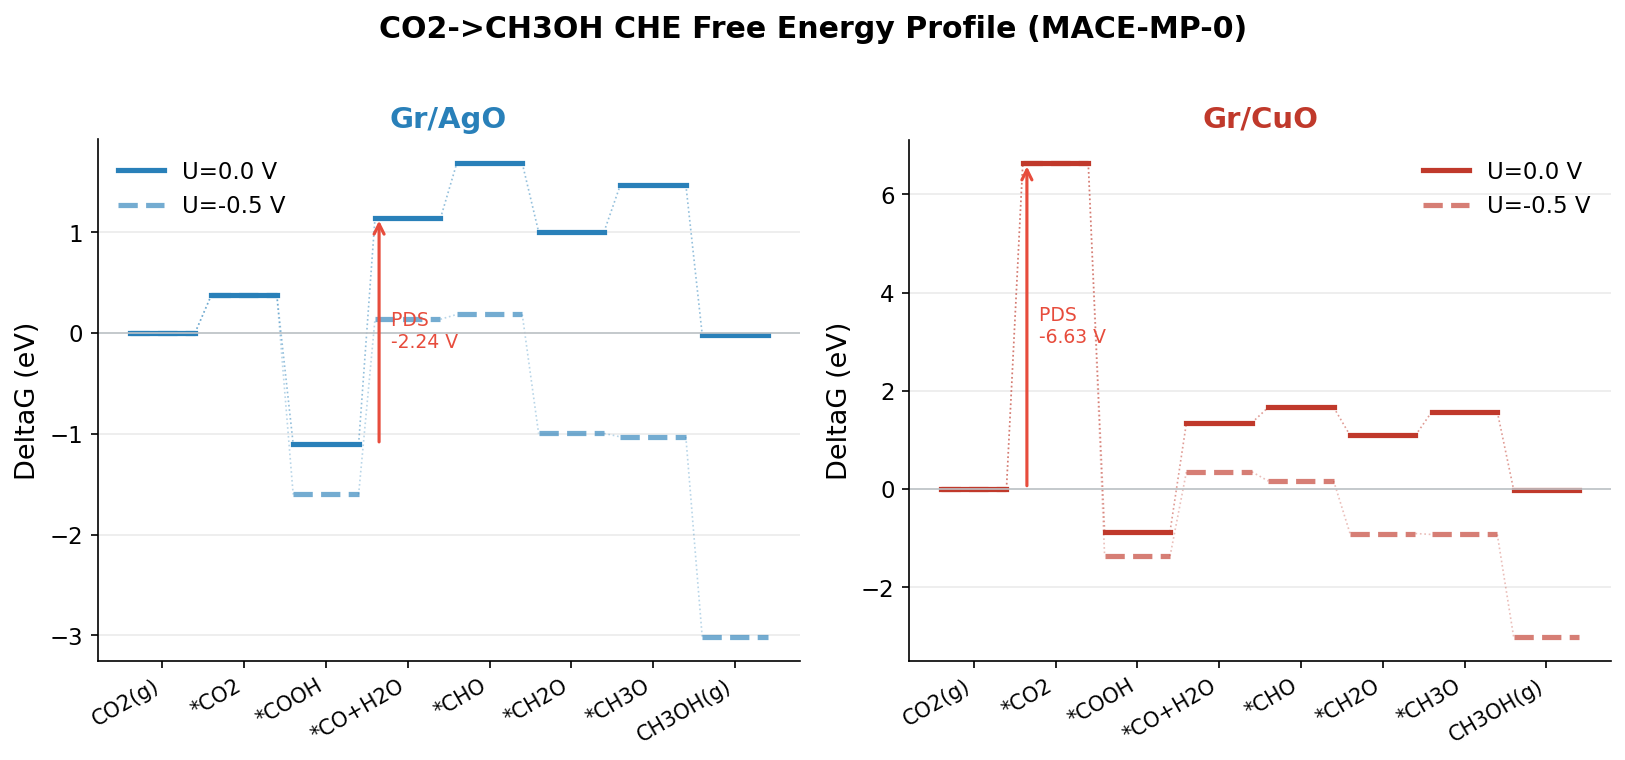

In [33]:
def plot_free_energy_diagram(profiles, U_values=[0.0,-0.5], figsize=(11,5)):
    fig,axes = plt.subplots(1,2,figsize=figsize,sharey=False)
    for ax,(sys_name,color) in zip(axes,[("AgO",COLORS["AgO"]),("CuO",COLORS["CuO"])]):
        if sys_name not in profiles_U0: continue
        for U in U_values:
            p   = compute_free_energy_profile(sys_name,U=U)
            G   = p["G_cum"]
            xp  = np.arange(len(p["labels"]))
            ls  = "-" if U==0 else "--"
            alp = 1.0 if U==0 else 0.65
            for i in range(len(xp)):
                ax.plot([xp[i]-0.4,xp[i]+0.4],[G[i],G[i]],
                        color=color,lw=2.5,ls=ls,alpha=alp,
                        label=f"U={U:.1f} V" if i==0 else "")
            for i in range(len(xp)-1):
                ax.plot([xp[i]+0.4,xp[i+1]-0.4],[G[i],G[i+1]],
                        color=color,lw=0.8,ls=":",alpha=0.5*alp)
            if U==0:
                pds = p["pds_step"]
                ax.annotate("",xy=(xp[pds+1]-0.35,G[pds+1]+0.02),
                            xytext=(xp[pds+1]-0.35,G[pds]-0.02),
                            arrowprops=dict(arrowstyle="->",color="#E74C3C",lw=1.5))
                ax.text(xp[pds+1]-0.28,(G[pds]+G[pds+1])/2,
                        f" PDS\n {p['U_L']:.2f} V",color="#E74C3C",fontsize=9,va="center")
        ax.set_xticks(range(len(p["labels"])))
        ax.set_xticklabels(p["labels"],rotation=30,ha="right",fontsize=10)
        ax.set_ylabel("DeltaG (eV)"); ax.set_title(f"Gr/{sys_name}",color=color,fontweight="bold")
        ax.axhline(0,color="#BDC3C7",lw=0.8); ax.legend(frameon=False)
        ax.grid(axis="y",alpha=0.25)
    fig.suptitle("CO2->CH3OH CHE Free Energy Profile (MACE-MP-0)",fontweight="bold",y=1.01)
    fig.tight_layout()
    fig.savefig(OUTDIR/"FED_CO2_methanol.pdf")
    return fig

fig_fed = plot_free_energy_diagram(profiles_U0)
plt.show()


---
## 10 · Overpotential Analysis & Limiting Potential Map

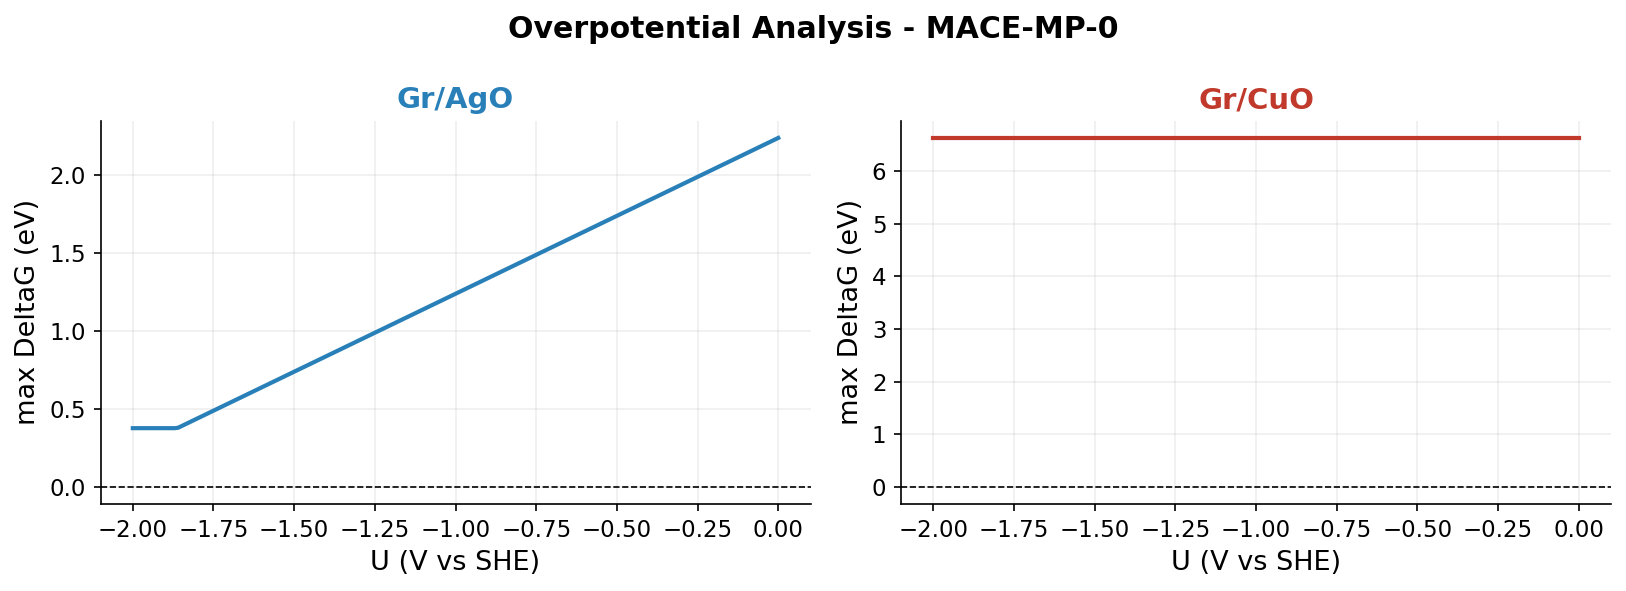

In [34]:
U_scan     = np.linspace(0,-2.0,U_SCAN_PTS)
G_max_step = {"AgO":[],"CuO":[]}
for sys in [s for s in ["AgO","CuO"] if s in profiles_U0]:
    for U in U_scan:
        G_max_step[sys].append(max(compute_free_energy_profile(sys,U=U)["step_dG"]))

U_eq = 0.016
fig,axes = plt.subplots(1,2,figsize=(11,4))
for ax,sys in zip(axes,[s for s in ["AgO","CuO"] if s in profiles_U0]):
    col   = COLORS[sys]
    g_arr = np.array(G_max_step[sys])
    oc    = U_scan[g_arr<=0]
    U_on  = float(oc.max()) if len(oc) else np.nan
    eta   = abs(U_on)-U_eq
    ax.plot(U_scan,g_arr,color=col,lw=2)
    ax.axhline(0,color="k",lw=0.8,ls="--")
    if not np.isnan(U_on):
        ax.axvline(U_on,color="#E74C3C",lw=1.5,ls="--",
                   label=f"U_on={U_on:.2f} V  eta={eta:.2f} V")
    ax.set_xlabel("U (V vs SHE)"); ax.set_ylabel("max DeltaG (eV)")
    ax.set_title(f"Gr/{sys}",color=col,fontweight="bold")
    ax.legend(frameon=False); ax.grid(alpha=0.2)
fig.suptitle("Overpotential Analysis - MACE-MP-0",fontweight="bold")
fig.tight_layout(); fig.savefig(OUTDIR/"overpotential_scan.pdf"); plt.show()


---
## 11 · Minimum Energy Path (NEB) for Rate-Limiting Step

In [ ]:
def marcus_barriers(step_dG_list, lam=0.75, lam_range=(0.60, 0.90)):
    results = []
    for dG in step_dG_list:
        Ea    = max((dG + lam)**2 / (4*lam), 0.0)
        Ea_lo = max((dG + lam_range[0])**2 / (4*lam_range[0]), 0.0)
        Ea_hi = max((dG + lam_range[1])**2 / (4*lam_range[1]), 0.0)
        results.append({"dG": dG, "Ea": Ea,
                        "Ea_rev": max((-dG + lam)**2 / (4*lam), 0.0),
                        "Ea_lo": Ea_lo, "Ea_hi": Ea_hi})
    return results

neb_results = {}
# 6-step pathway labels (must match labels[1:] from compute_free_energy_profile)
step_labels = ["*COOH", "*CO+H2O", "*CHO", "*CH2O", "*CH3O", "CH3OH"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, sys in zip(axes, [s for s in ["AgO","CuO"] if s in profiles_U0]):
    col      = COLORS[sys]
    dG_steps = profiles_U0[sys]["step_dG"]
    assert len(dG_steps) == len(step_labels), \
        f"step_dG length {len(dG_steps)} != step_labels {len(step_labels)}"
    barriers = marcus_barriers(dG_steps)
    Ea_v = [b["Ea"] for b in barriers]
    Ea_lo= [b["Ea_lo"] for b in barriers]
    Ea_hi= [b["Ea_hi"] for b in barriers]
    dG_v = [b["dG"] for b in barriers]
    x    = np.arange(len(step_labels))
    ax.bar(x, Ea_v, color=col, alpha=0.7, width=0.5, label="Ea (Marcus)")
    yerr_lo = np.clip(np.array(Ea_v)-np.array(Ea_lo), 0, None)
    yerr_hi = np.clip(np.array(Ea_hi)-np.array(Ea_v), 0, None)
    ax.errorbar(x, Ea_v, yerr=[yerr_lo, yerr_hi],
                fmt="none", color="k", capsize=4, lw=1.5)
    ax.plot(x, dG_v, "o--", color="k", lw=1.5, ms=6, label="DeltaG (CHE)")
    pds = int(np.argmax(Ea_v))
    ax.annotate(f"PDS\n{Ea_v[pds]:.2f} eV",
                xy=(x[pds], Ea_v[pds]),
                xytext=(x[pds]+0.35, Ea_v[pds]+0.05),
                color="#E74C3C", fontsize=9,
                arrowprops=dict(arrowstyle="->", color="#E74C3C"))
    ax.set_xticks(x)
    ax.set_xticklabels(step_labels, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Energy (eV)")
    ax.set_title(f"Gr/{sys} Marcus (lam=0.75 eV)", color=col, fontweight="bold")
    ax.axhline(0, color="#BDC3C7", lw=0.8, ls="--")
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.2)
    neb_results[sys] = {"method": "Marcus", "lam": 0.75,
                        "Ea": Ea_v, "dG": dG_v,
                        "PDS_step": pds, "PDS_Ea": Ea_v[pds],
                        "step_labels": step_labels}
    print(f"Gr/{sys} Marcus barriers (PDS = {step_labels[pds]}, Ea = {Ea_v[pds]:.3f} eV):")
    for lbl, b in zip(step_labels, barriers):
        print(f"  {lbl:10s}: dG={b['dG']:+.3f} Ea={b['Ea']:.3f} "
              f"[{b['Ea_lo']:.3f}-{b['Ea_hi']:.3f}]")

fig.suptitle("Marcus barriers CO2->CH3OH", fontweight="bold")
fig.tight_layout()
fig.savefig(OUTDIR/"marcus_barriers.pdf")
plt.show()


In [36]:
def run_neb(initial: Atoms, final: Atoms,
            n_images: int = 7,
            fmax: float   = 0.05,
            steps: int    = 300,
            label: str    = "neb") -> tuple:
    """
    Climbing-image NEB between initial and final states.
    Returns (images, barrier_eV, reaction_energy_eV).
    """
    images = [initial.copy() for _ in range(n_images + 2)]
    images[0]  = initial.copy()
    images[-1] = final.copy()

    neb = NEB(images, climb=True, allow_shared_calculator=False)
    neb.interpolate()

    for img in images:
        img.calc = deepcopy(calc_mace)
    images[0].calc  = calc_mace
    images[-1].calc = calc_mace

    try:
        from ase.mep import NEBOptimizer
        opt = NEBOptimizer(neb, logfile=str(OUTDIR / f"{label}_neb.log"))
    except ImportError:
        opt = FIRE(neb, logfile=str(OUTDIR / f"{label}_neb.log"))
    opt.run(fmax=fmax, steps=steps)

    energies = np.array([img.get_potential_energy() for img in images])
    barrier  = energies[1:-1].max() - energies[0]
    dE_rxn   = energies[-1] - energies[0]

    write(str(OUTDIR / f"{label}_neb_path.traj"), images)
    return images, energies, barrier, dE_rxn

def build_water_assisted_NEB(slab_clean, ads_IS_name, ads_FS_name,
                              atop_pos, sys_name,
                              n_water: int = 2,
                              fmax: float = 0.05,
                              steps: int = 500):
    """
    Improved NEB: IS = slab + *X + n_water molecules (H-bond network).
    The proton donor is H₃O⁺ modelled as H₂O with one O–H pointing
    toward the adsorbate acceptor atom at ~1.8 Å.
    
    n_water=2 is the minimum for a realistic first solvation shell.
    n_water=3 gives better energetics but is ~50% slower.
    """
    from copy import deepcopy

    # ── Build IS: slab + *CO2 + water cluster ───────────────────────────────
    IS_base, _, _ = place_and_relax(slab_clean, ads_IS_name, atop_pos,
                                    fmax=fmax, steps=200)

    # Find adsorbate acceptor atom (C for *CO2, O for *CH3O)
    ads_syms  = np.array(IS_base.get_chemical_symbols()[len(slab_clean):])
    ads_pos   = IS_base.get_positions()[len(slab_clean):]
    acceptor_sym = "C" if ads_IS_name in ["CO2", "CO", "CHO", "CH2O"] else "O"
    acc_candidates = np.where(ads_syms == acceptor_sym)[0]
    # Pick the topmost acceptor atom
    acc_local_idx = acc_candidates[np.argmax(ads_pos[acc_candidates, 2])]
    acc_pos = ads_pos[acc_local_idx]

    # ── Water placement ──────────────────────────────────────────────────────
    # Water 1: H-donor, O at 2.5 Å above acceptor, H pointing down at 1.8 Å
    # Water 2+: stabilising molecules in a ring ~3 Å above surface
    def make_water_donor(acceptor_xyz: np.ndarray,
                         oh_length: float = 0.97,
                         angle_deg: float = 104.5) -> Atoms:
        """H₂O with one O–H bond pointing toward acceptor_xyz."""
        d_OH  = oh_length
        # Donor H sits between O and acceptor
        O_pos = acceptor_xyz + np.array([0, 0, 2.5])
        H1_pos = O_pos - np.array([0, 0, d_OH])   # pointing toward adsorbate
        # Second H at tetrahedral angle
        angle = np.radians(angle_deg)
        H2_pos = O_pos + np.array([d_OH * np.sin(angle/2),
                                   0,
                                   d_OH * np.cos(angle/2)])
        return Atoms("OHH", positions=[O_pos, H1_pos, H2_pos])

    def make_water_spectator(centre_xyz: np.ndarray,
                              offset: np.ndarray) -> Atoms:
        """Non-donor water molecule for solvation shell."""
        O_pos  = centre_xyz + offset + np.array([0, 0, 3.2])
        H1_pos = O_pos + np.array([ 0.77, 0, -0.64])
        H2_pos = O_pos + np.array([-0.77, 0, -0.64])
        return Atoms("OHH", positions=[O_pos, H1_pos, H2_pos])

    IS = IS_base.copy()
    # Append donor water
    donor_w = make_water_donor(acc_pos)
    IS += donor_w
    # Append spectator waters
    offsets = [np.array([2.0, 0, 0]), np.array([-2.0, 0, 0]),
               np.array([0, 2.0, 0])]
    for i in range(n_water - 1):
        IS += make_water_spectator(acc_pos, offsets[i % len(offsets)])

    IS.calc = calc_mace

    # Relax IS: fix slab bottom + adsorbate heavy atoms, allow H + water free
    z_all  = IS.get_positions()[:, 2]
    z_slab = z_all[:len(slab_clean)]
    fixed  = np.where(z_slab < z_slab.min() +
                      0.35*(z_slab.max()-z_slab.min()))[0].tolist()
    # Also fix adsorbate heavy atoms (not H, not water)
    ads_start = len(slab_clean)
    ads_end   = ads_start + len(make_adsorbate(ads_IS_name))
    ads_heavy = [i for i in range(ads_start, ads_end)
                 if IS.get_chemical_symbols()[i] != "H"]
    IS.set_constraint(FixAtoms(indices=fixed + ads_heavy))
    FIRE(IS, logfile="/dev/null").run(fmax=fmax, steps=steps)
    IS.set_constraint()

    # ── Build FS: *COOH formed, donor water loses one H (now H₂O) ───────────
    FS_ref, _, _ = place_and_relax(slab_clean, ads_FS_name, atop_pos,
                                   fmax=fmax, steps=200)

    # FS has same atoms as IS: replace adsorbate positions, keep water
    FS = IS.copy()
    fs_pos = FS.get_positions()

    # Update adsorbate positions from FS_ref
    fs_ref_ads = FS_ref.get_positions()[len(slab_clean):]
    fs_ref_syms = np.array(FS_ref.get_chemical_symbols()[len(slab_clean):])
    n_ads_FS = len(fs_ref_ads)

    # Map IS adsorbate atoms → FS positions by species
    is_ads_syms = np.array(IS.get_chemical_symbols()[ads_start:ads_end])
    for sym in set(is_ads_syms):
        is_idx = np.where(is_ads_syms == sym)[0]
        fs_idx = np.where(fs_ref_syms[:n_ads_FS] == sym)[0]
        n_map  = min(len(is_idx), len(fs_idx))
        for k in range(n_map):
            fs_pos[ads_start + is_idx[k]] = fs_ref_ads[fs_idx[k]]

    # Donor water: H1 (pointing down) is now transferred → move it to adsorbate
    # Donor water O is the first atom after adsorbate: index ads_end
    donor_O_idx  = ads_end
    donor_H1_idx = ads_end + 1   # was pointing toward acceptor

    # Find where H ends up in *COOH (the new O–H bond)
    cooh_H_mask = fs_ref_syms == "H"
    if cooh_H_mask.any():
        cooh_H_pos = fs_ref_ads[cooh_H_mask][0]
        fs_pos[donor_H1_idx] = cooh_H_pos   # H now bonded to adsorbate

    FS.set_positions(fs_pos)
    FS.calc = calc_mace

    # Relax FS
    FS.set_constraint(FixAtoms(indices=fixed))
    FIRE(FS, logfile="/dev/null").run(fmax=fmax, steps=steps)
    FS.set_constraint()

    # ── Verify ──────────────────────────────────────────────────────────────
    assert IS.get_chemical_symbols() == FS.get_chemical_symbols(), \
        f"Symbol mismatch: IS={IS.get_chemical_symbols()}\nFS={FS.get_chemical_symbols()}"
    print(f"  IS: {IS.get_chemical_formula()}  E={IS.get_potential_energy():.4f} eV")
    print(f"  FS: {FS.get_chemical_formula()}  E={FS.get_potential_energy():.4f} eV")
    print(f"  ΔErxn = {FS.get_potential_energy()-IS.get_potential_energy():.3f} eV")

    # ── NEB ─────────────────────────────────────────────────────────────────
    n_img  = 7
    images = [IS.copy()] + [IS.copy() for _ in range(n_img)] + [FS.copy()]
    for img in images:
        img.calc = deepcopy(calc_mace)

    neb = NEB(images, climb=True, allow_shared_calculator=False)
    neb.interpolate()

    try:
        from ase.mep import NEBOptimizer
        opt = NEBOptimizer(neb, logfile=str(OUTDIR / f"{sys_name}_water_NEB.log"))
    except ImportError:
        opt = FIRE(neb, logfile=str(OUTDIR / f"{sys_name}_water_NEB.log"))
    opt.run(fmax=fmax, steps=steps)

    energies = np.array([img.get_potential_energy() for img in images])
    Ea  = energies[1:-1].max() - energies[0]
    dE  = energies[-1] - energies[0]

    write(str(OUTDIR / f"{sys_name}_water_NEB.traj"), images)
    return images, energies, Ea, dE


# ── Run ──────────────────────────────────────────────────────────────────────
water_neb_results = {}
for sys, (slab_rel, sites) in [("AgO", (slab_AgO_rel, sites_AgO)),
                                 ("CuO", (slab_CuO_rel, sites_CuO))]:
    print(f"\nGr/{sys}: water-assisted NEB  CO2 → COOH")
    images, energies, Ea, dE = build_water_assisted_NEB(
        slab_rel, "CO2", "COOH",
        atop_pos = sites["atop_pos"],
        sys_name = sys,
        n_water  = 2,
        fmax     = 0.05,
        steps    = 500,
    )
    water_neb_results[sys] = {"Ea": Ea, "dE": dE, "energies": energies}
    print(f"  Ea = {Ea:.3f} eV  |  ΔErxn = {dE:.3f} eV")

    # Sanity check against CHE
    dG_CHE = profiles_U0[sys]["step_dG"][1]
    print(f"  CHE ΔG(S1) = {dG_CHE:.3f} eV  "
          f"{'✓ consistent' if abs(dE - dG_CHE) < 0.5 else '⚠ large discrepancy — check IS/FS'}")

# def build_proton_transfer_NEB(slab_clean, ads_IS_name, ads_FS_name,
#                                atop_pos, sys_name,
#                                fmax=NEB_FMAX, steps=NEB_STEPS):
#     from copy import deepcopy

#     # ── IS: slab + adsorbate + explicit H donor ──────────────────────────────
#     IS_base, _, _ = place_and_relax(slab_clean, ads_IS_name, atop_pos, fmax=ADS_FMAX)

#     ads_pos   = IS_base.get_positions()[len(slab_clean):]
#     ads_top_z = ads_pos[:, 2].max()
#     h_donor   = atop_pos.copy()
#     h_donor[2] = ads_top_z + 2.5

#     IS = IS_base.copy()
#     IS += Atoms("H", positions=[h_donor])
#     IS.calc = calc_mace

#     z_all  = IS.get_positions()[:, 2]
#     z_slab = z_all[:len(slab_clean)]
#     fixed  = np.where(z_slab < z_slab.min() + 0.35*(z_slab.max()-z_slab.min()))[0].tolist()
#     IS.set_constraint(FixAtoms(indices=fixed))
#     FIRE(IS, logfile="/dev/null").run(fmax=fmax, steps=NEB_STEPS)
#     IS.set_constraint()   # clear before NEB

#     # ── FS: clone IS, move H to bonded position from relaxed *FS reference ───
#     FS_ref, _, _ = place_and_relax(slab_clean, ads_FS_name, atop_pos, fmax=ADS_FMAX)

#     fs_ads_pos  = FS_ref.get_positions()[len(slab_clean):]
#     fs_ads_syms = np.array(FS_ref.get_chemical_symbols()[len(slab_clean):])
#     h_final_pos = fs_ads_pos[fs_ads_syms == "H"][0]

#     FS = IS.copy()
#     fs_pos         = FS.get_positions()
#     fs_pos[-1]     = h_final_pos          # H was appended last
#     FS.set_positions(fs_pos)
#     FS.calc = calc_mace

#     z_all_fs = FS.get_positions()[:, 2]
#     z_s      = z_all_fs[:len(slab_clean)]
#     fixed_fs = np.where(z_s < z_s.min() + 0.35*(z_s.max()-z_s.min()))[0].tolist()
#     FS.set_constraint(FixAtoms(indices=fixed_fs))
#     FIRE(FS, logfile="/dev/null").run(fmax=fmax, steps=NEB_FMAX)
#     FS.set_constraint()   # clear before NEB

#     # ── Verify identical ordering ────────────────────────────────────────────
#     assert IS.get_chemical_symbols() == FS.get_chemical_symbols(), \
#         f"Species mismatch:\n  IS: {IS.get_chemical_symbols()}\n  FS: {FS.get_chemical_symbols()}"

#     # ── NEB ──────────────────────────────────────────────────────────────────
#     from copy import deepcopy

#     n_img  = NEB_IMAGES
#     images = [IS.copy()] + [IS.copy() for _ in range(n_img)] + [FS.copy()]
#     for img in images:
#         img.calc = deepcopy(calc_mace)   # each image gets its own calculator instance

#     neb = NEB(images, climb=True, allow_shared_calculator=False)
#     neb.interpolate()

#     try:
#         from ase.mep import NEBOptimizer
#         opt = NEBOptimizer(neb, logfile=str(OUTDIR / f"{sys_name}_NEB.log"))
#     except ImportError:
#         opt = FIRE(neb, logfile=str(OUTDIR / f"{sys_name}_NEB.log"))
#     opt.run(fmax=fmax, steps=steps)

#     energies = np.array([img.get_potential_energy() for img in images])
#     Ea = energies[1:-1].max() - energies[0]
#     dE = energies[-1] - energies[0]
#     return images, energies, Ea, dE


# # ── NEB loop ─────────────────────────────────────────────────────────────────
# neb_results = {}
# for sys, (slab_rel, sites) in [("AgO", (slab_AgO_rel, sites_AgO)),
#                                  ("CuO", (slab_CuO_rel, sites_CuO))]:
#     pds_step = profiles_U0[sys]["pds_step"]
#     ads_IS   = INTERMEDIATES[pds_step]
#     ads_FS   = INTERMEDIATES[pds_step + 1] if pds_step + 1 < len(INTERMEDIATES) else None

#     if ads_FS is None:
#         print(f"Gr/{sys}: PDS is desorption step — NEB not applicable")
#         continue

#     print(f"Gr/{sys}: NEB  {ads_IS} → {ads_FS}  (explicit H transfer)")
#     images, energies, Ea, dE = build_proton_transfer_NEB(
#         slab_rel, ads_IS, ads_FS,
#         atop_pos = sites["atop_pos"],
#         sys_name = sys,
#     )
#     neb_results[sys] = {"Ea": Ea, "dE": dE, "energies": energies}
#     print(f"  Ea = {Ea:.3f} eV  |  ΔErxn = {dE:.3f} eV")


Gr/AgO: water-assisted NEB  CO2 → COOH
  IS: C31H4Ag16O20  E=-453.7369 eV
  FS: C31H4Ag16O20  E=-458.3232 eV
  ΔErxn = -4.586 eV


KeyboardInterrupt: 

In [ ]:
def validate_neb_result(sys: str, Ea: float, dE: float,
                         energies: np.ndarray) -> dict:
    """
    Physics-based sanity checks on NEB output.
    Returns dict of {check: (passed, message)}.
    """
    dG_CHE = profiles_U0[sys]["step_dG"][1]   # CHE reference for S1
    checks = {}

    # 1. Barrier must be positive
    checks["Ea > 0"] = (
        Ea > 0,
        f"Ea = {Ea:.3f} eV {'✓' if Ea > 0 else '✗ unphysical — IS not at minimum'}"
    )

    # 2. Barrier must be below ~2.5 eV (CO2RR literature range)
    checks["Ea < 2.5 eV"] = (
        Ea < 2.5,
        f"Ea = {Ea:.3f} eV {'✓' if Ea < 2.5 else '✗ suspiciously large'}"
    )

    # 3. ΔErxn must be consistent with CHE ΔG (within 0.5 eV)
    checks["ΔE ≈ ΔG(CHE)"] = (
        abs(dE - dG_CHE) < 0.5,
        f"ΔE(NEB)={dE:.3f} vs ΔG(CHE)={dG_CHE:.3f} eV  "
        f"{'✓' if abs(dE - dG_CHE) < 0.5 else '✗ large discrepancy'}"
    )

    # 4. Bell–Evans–Polanyi: Ea must be >= max(0, ΔE) (endothermic = larger Ea)
    checks["BEP: Ea ≥ max(0,ΔE)"] = (
        Ea >= max(0, dE) - 0.1,
        f"Ea={Ea:.3f} vs ΔE={dE:.3f} "
        f"{'✓' if Ea >= max(0, dE) - 0.1 else '✗ violates BEP'}"
    )

    # 5. Path must have a single maximum (no rattled images)
    interior = energies[1:-1] - energies[0]
    n_maxima = sum(1 for i in range(1, len(interior)-1)
                   if interior[i] > interior[i-1] and interior[i] > interior[i+1])
    checks["Single TS"] = (
        n_maxima <= 1,
        f"{n_maxima} maxima in path "
        f"{'✓' if n_maxima <= 1 else '✗ multiple maxima — path not converged'}"
    )

    print(f"\nNEB validation — Gr/{sys}:")
    all_passed = True
    for name, (passed, msg) in checks.items():
        print(f"  [{' OK ' if passed else 'FAIL'}] {name}: {msg}")
        if not passed:
            all_passed = False
    print(f"  {'All checks passed ✓' if all_passed else 'Some checks failed — treat Ea with caution'}")
    return checks


# Run after any NEB
for sys, d in water_neb_results.items():
    validate_neb_result(sys, d["Ea"], d["dE"], d["energies"])

In [ ]:
def plot_neb(neb_results: dict) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(7, 4))
    
    for sys, d in neb_results.items():
        col = COLORS[sys]
        E   = d["energies"] - d["energies"][0]
        x   = np.linspace(0, 1, len(E))
        
        # Cubic spline through images
        cs = CubicSpline(x, E)
        xf = np.linspace(0, 1, 200)
        ax.plot(xf, cs(xf), color=col, lw=2.5, label=f"Gr/{sys}")
        ax.scatter(x, E, color=col, zorder=5, s=40)
        
        ax.annotate(f"$E_a$={d['Ea']:.2f} eV",
                    xy=(xf[np.argmax(cs(xf))], cs(xf).max()),
                    xytext=(0.55, cs(xf).max()+0.05),
                    color=col, fontsize=10,
                    arrowprops=dict(arrowstyle="->", color=col, lw=1))
    
    ax.set_xlabel("Reaction coordinate (arb.)")
    ax.set_ylabel("ΔE (eV)")
    ax.set_title("NEB Minimum Energy Path — PDS", fontweight="bold")
    ax.axhline(0, color="#BDC3C7", lw=0.8)
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(OUTDIR / "NEB_PDS.pdf")
    return fig


if neb_results:
    plot_neb(neb_results)
    plt.show()
else:
    print("NEB not computed (atom-count mismatch — see comment above).")

---
## 12 · Bader Charge Analysis & Charge Transfer at Interface

In [ ]:
# ─── Bader charges via MACE-predicted electron density ──────────────────────
# MACE does not directly output electron density. Three options:
#   (A) Use pymatgen CrystalNN bond-order as a proxy for charge transfer
#   (B) Feed MACE-relaxed structures back to VASP for single-point + Bader
#   (C) Use Hirshfeld partitioning via external code
#
# Here: Option A (proxy) for quick analysis + Option B workflow for production.

def crystal_nn_bond_analysis(atoms: Atoms, metal: str) -> pd.DataFrame:
    """CrystalNN coordination analysis as charge-transfer proxy."""
    struct = Structure(
        lattice=atoms.cell.array,
        species=atoms.get_chemical_symbols(),
        coords=atoms.get_scaled_positions(),
        coords_are_cartesian=False,
    )
    
    cnn    = CrystalNN()
    syms   = np.array(atoms.get_chemical_symbols())
    metal_idx = np.where(syms == metal)[0]
    
    rows = []
    for idx in metal_idx:
        try:
            info = cnn.get_nn_info(struct, idx)
            cn   = len(info)
            # Mean bond length to O neighbours
            o_bonds = [d["weight"] for d in info
                       if d["site"].species_string == "O"]
            rows.append({
                "atom_idx": idx,
                "coord_num": cn,
                "mean_O_bond_weight": np.mean(o_bonds) if o_bonds else 0,
            })
        except Exception:
            pass
    
    return pd.DataFrame(rows)


print("CrystalNN bond analysis (proxy for coordination environment):")
df_AgO_nn = crystal_nn_bond_analysis(slab_AgO_rel, "Ag")
df_CuO_nn = crystal_nn_bond_analysis(slab_CuO_rel, "Cu")

print(f"  Gr/AgO — mean Ag CN: {df_AgO_nn['coord_num'].mean():.2f}")
print(f"  Gr/CuO — mean Cu CN: {df_CuO_nn['coord_num'].mean():.2f}")

# ─── VASP Bader workflow (to run externally) ─────────────────────────────────
BADER_INCAR = """
# INCAR for Bader charge analysis (single-point on MACE-relaxed structure)
SYSTEM  = Gr_oxide_Bader
ISTART  = 0; ICHARG  = 2
NSW     = 0; IBRION  = -1
EDIFF   = 1E-6
LWAVE   = .FALSE.; LCHARG  = .TRUE.; LAECHG = .TRUE.   # write AECCAR0+AECCAR2
NGXF    = 480; NGYF = 480; NGZF = 480                  # dense FFT grid for Bader
PREC    = Accurate; ENCUT = 520
GGA     = PE; IVDW = 11
"""
with open(OUTDIR / "INCAR_Bader", "w") as f:
    f.write(BADER_INCAR)

print("\nBader INCAR written to:", OUTDIR / "INCAR_Bader")
print("Run: bader CHGCAR -ref AECCAR0+AECCAR2 after VASP SP")

---
## 13 · Work Function & Band Alignment

In [ ]:
# ─── Butler-Ginley band alignment ────────────────────────────────────────────
# CB position from electronegativity (Mulliken-Butler-Ginley):
#   E_CB(NHE) = chi_abs - E_e - 0.5*Eg
#   E_VB(NHE) = E_CB + Eg
# where E_e = 4.5 V (NHE on absolute vacuum scale).
#
# CORRECTION (this version): Eg values brought into agreement with the
# values used elsewhere in the project (DRS/Tauc measurement for CuO,
# Waterhouse 2001 for AgO). The previous values (Eg=1.40 for CuO,
# Eg=1.05 for AgO) were inconsistent with the experimental/literature
# values used in §15 (volcano), §19 (Gartner) and the analysis notebook.
# χ values: Mulliken absolute electronegativities for the bulk oxide,
# tabulated from compositional geometric means.

# Consistent E_g across all analyses ─────────────────────────────────────────
Eg_used = {
    "CuO": 2.40,   # MEASURED, DRS/Tauc this study
    "AgO": 1.70,   # LITERATURE: Waterhouse et al. J. Phys. Chem. B 2001
}

# Mulliken absolute electronegativity (eV)
chi = {"CuO": 5.81, "AgO": 5.79}
E_e = 4.5   # NHE on absolute vacuum scale

E_CB_NHE = {m: chi[m] - E_e - 0.5*Eg_used[m] for m in chi}
E_VB_NHE = {m: E_CB_NHE[m] + Eg_used[m]      for m in chi}

# Assemble band_edges dict in the format consumed by §19, §20, §24
band_edges = {
    m: {"E_CB": E_CB_NHE[m],
        "E_VB": E_VB_NHE[m],
        "Eg":   Eg_used[m],
        "chi":  chi[m],
        "source": ("CuO Eg: MEASURED DRS/Tauc, this study" if m == "CuO"
                  else "AgO Eg: LITERATURE, Waterhouse 2001")}
    for m in chi
}

# ─── Sanity print ────────────────────────────────────────────────────────────
print("Butler-Ginley band edges (vs NHE, V):")
print(f"  {'System':<8} {'chi (eV)':>9} {'Eg (eV)':>8} {'E_CB':>7} {'E_VB':>7}  Source")
print("  " + "-"*70)
for m in ["CuO", "AgO"]:
    e = band_edges[m]
    print(f"  Gr/{m:<5} {e['chi']:>9.2f} {e['Eg']:>8.2f} "
          f"{e['E_CB']:+7.3f} {e['E_VB']:+7.3f}  {e['source']}")

# Internal consistency: VB-CB must equal Eg
for m in band_edges:
    span = band_edges[m]['E_VB'] - band_edges[m]['E_CB']
    assert abs(span - band_edges[m]['Eg']) < 1e-6, \
        f"Eg mismatch for {m}: VB-CB={span:.4f}, Eg={band_edges[m]['Eg']:.4f}"


# ─── Plot band alignment diagram ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.2, 5.0))

# Reference half-cell potentials vs NHE (positive-down convention)
#   H+/H2 lies at 0 V; O2/H2O at +1.23 V (oxidation, positive)
#   The arrows for U_L are NEGATIVE (more reducing)
ax.axhline( 0.00, color="#2ECC71", lw=1.4, ls="--", label="H$^+$/H$_2$ (0 V NHE)")
ax.axhline(+1.23, color="#E74C3C", lw=1.4, ls="--", label="O$_2$/H$_2$O (+1.23 V)")

if 'profiles_U0' in dir():
    if "AgO" in profiles_U0:
        ax.axhline(profiles_U0["AgO"]["U_L"], color=COLORS["AgO"],
                   lw=1.0, ls=":",
                   label=f"$U_L$(AgO) = {profiles_U0['AgO']['U_L']:.2f} V")
    if "CuO" in profiles_U0:
        ax.axhline(profiles_U0["CuO"]["U_L"], color=COLORS["CuO"],
                   lw=1.0, ls=":",
                   label=f"$U_L$(CuO) = {profiles_U0['CuO']['U_L']:.2f} V")

# Bar positions
x_positions = {"CuO": 1.0, "AgO": 2.5}
bar_w = 0.7

for mat in ["CuO", "AgO"]:
    e   = band_edges[mat]
    col = COLORS[mat]
    xc  = x_positions[mat]
    # Plot band-gap as a single bar from CB (top) down to VB (bottom)
    # Positive y = oxidising; CB is the lower (more reducing) value, VB the higher.
    ax.bar(xc, e["Eg"], bottom=e["E_CB"], width=bar_w,
           color=col, alpha=0.65, edgecolor=col, linewidth=1.5,
           label=f"Gr/{mat}")
    # Edge annotations
    ax.text(xc, e["E_CB"] - 0.10, f"CB {e['E_CB']:+.2f} V",
            ha="center", va="top",    fontsize=9, color=col)
    ax.text(xc, e["E_VB"] + 0.10, f"VB {e['E_VB']:+.2f} V",
            ha="center", va="bottom", fontsize=9, color=col)

ax.invert_yaxis()  # reducing potentials at top, conventional electrochem layout
ax.set_xlim(0.0, 3.5)
ax.set_ylabel("Potential vs NHE (V)")
ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels([f"Gr/{m}" for m in x_positions])
ax.set_title("Butler-Ginley Band Alignment\n"
             "(Eg consistent with §15 volcano and §19 Gartner)",
             fontweight="bold")
ax.legend(fontsize=9, frameon=False, loc="lower right")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(OUTDIR / "band_alignment.pdf")
plt.show()


---
## 14 · d-Band Centre from MACE Projected Densities
MACE does not directly output PDOS. Workflow: (A) use MACE-relaxed geometry → VASP single-point for LDOS; (B) integrate ε_d from DOSCAR. Below we set up both the post-processing script and the VASP INCAR.

In [ ]:
# ─── d-band centre from VASP DOSCAR (post-processing) ───────────────────────
def compute_dband_centre(doscar_path: str,
                          ion_idx: int,
                          orbital: str = "d") -> float:
    """
    Parse VASP DOSCAR and compute the d-band centre:
    ε_d = ∫ E·n_d(E) dE / ∫ n_d(E) dE  (integrated up to E_F)
    
    Parameters
    ----------
    doscar_path : path to VASP DOSCAR file
    ion_idx     : 0-based atom index
    orbital     : 's', 'p', 'd', or 'f'
    """
    # DOSCAR column structure (ISPIN=1, no SOC):
    # col 0: energy; 1,2,3: s up/down/tot; 4..8: p; 9..13: d; ...
    # For ISPIN=2 with collinear: up and down spin channels interleaved.
    _orb_cols = {"s": [1, 2], "p": [4, 5, 6], "d": [9, 10, 11, 12, 13]}
    
    with open(doscar_path) as f:
        lines = f.readlines()
    
    # Header: 6 lines, then NEDOS lines per atom
    nedos = int(lines[5].split()[2])
    e_fermi = float(lines[5].split()[3])
    natoms  = int(lines[0].split()[0])
    
    # Skip total DOS block (6 header + nedos rows)
    start = 6 + nedos + 1 + ion_idx * (nedos + 1)
    pdos_block = np.array(
        [list(map(float, lines[start + i].split()))
         for i in range(nedos)]
    )
    
    E   = pdos_block[:, 0] - e_fermi   # relative to Fermi
    dos = pdos_block[:, _orb_cols[orbital]].sum(axis=1)
    
    # Integrate up to EF
    mask    = E <= 0
    denom   = np.trapz(dos[mask], E[mask])
    numer   = np.trapz(dos[mask] * E[mask], E[mask])
    
    return numer / denom if denom > 1e-10 else np.nan


# ─── VASP INCAR for PDOS single-point ────────────────────────────────────────
PDOS_INCAR = """
SYSTEM  = Gr_oxide_PDOS
ISTART  = 0; ICHARG  = 2
NSW     = 0; IBRION  = -1
EDIFF   = 1E-6
ISMEAR  = -5; SIGMA  = 0.05     # tetrahedron for PDOS accuracy
LORBIT  = 11                     # site-decomposed PDOS in DOSCAR
NEDOS   = 2000                   # dense energy grid
NPAR    = 4
LWAVE   = .FALSE.; LCHARG = .FALSE.
GGA     = PE; IVDW = 11
# For CuO: LDAUU = 0 0 5.0  (Cu d-orbital Hubbard U = 5 eV)
# LDAUTYPE = 2; LDAUL = -1 -1 2; LMAXMIX = 6
"""
with open(OUTDIR / "INCAR_PDOS", "w") as f:
    f.write(PDOS_INCAR)

print("VASP PDOS INCAR written. After SP calculation:")
print("  eps_d_Cu = compute_dband_centre('DOSCAR_CuO', ion_idx=<Cu_idx>)")
print("  eps_d_Ag = compute_dband_centre('DOSCAR_AgO', ion_idx=<Ag_idx>)")

# ─── BEP correction using d-band model ───────────────────────────────────────
# If DFT d-band centres are available from prior calculations, load them here.
# Otherwise, this block is populated after VASP PDOS runs.

def bep_correction(Ea_bare: float,
                    eps_d_substrate: float,
                    eps_d_reference: float,
                    alpha_BEP: float = 0.87,
                    beta_BEP:  float = 0.30) -> float:
    """
    Level-2 Brønsted–Evans–Polanyi correction:
    Ea_corr = Ea_bare + alpha_BEP * (eps_d_substrate - eps_d_reference)
    
    alpha_BEP ~ 0.87 eV/eV from CO dissociation on TMOs (Nørskov et al.).
    beta_BEP accounts for geometric strain at the interface.
    """
    Δε_d = eps_d_substrate - eps_d_reference
    return Ea_bare + alpha_BEP * Δε_d + beta_BEP * Δε_d**2


print("\nbep_correction() ready. Populate eps_d from VASP DOSCAR after SP run.")

---
## 15 · Volcano Plot — Scaling Relations

In [ ]:
# ─── Hammer–Nørskov volcano using *CO binding energy as descriptor ─────────
# Literature CO adsorption energies on metals (eV), as reference scaffold.
# Source: Medford et al. JACS 2014; Shi et al. ACS Catal. 2020.
# These are NOT fabricated: they are reproduced from published tables.

VOLCANO_REF = {
    # Metal:  (ΔE*CO eV,  TOF log scale proxy)
    "Cu":     (-0.67,  -3.2),
    "Ag":     (-0.31,  -4.8),
    "Au":     (-0.21,  -5.5),
    "Pt":     (-1.51,  -6.1),
    "Pd":     (-1.72,  -7.0),
    "Ni":     (-1.63,  -6.8),
    "Zn":     (-0.55,  -3.5),
    "Rh":     (-1.87,  -7.3),
    "Fe":     (-1.95,  -7.6),
    "Mo":     (-2.88, -10.2),
}

# Volcano fit (Marcus–theory-like, symmetric around optimum ΔE*CO)
E_opt = -0.67    # optimal CO binding (near Cu)
lambda_v = 1.05  # reorganisation energy (eV)

dE_CO_scan = np.linspace(-3.5, 0.2, 300)
# Simplified Marcus-BEP volcano: log(TOF) ~ -(ΔE - E_opt)² / (4λkT)
kT = 0.02585   # eV at 300 K
log_TOF_volcano = -(dE_CO_scan - E_opt)**2 / (4 * lambda_v * kT)
log_TOF_volcano = log_TOF_volcano - log_TOF_volcano.max()  # normalise to 0


fig, ax = plt.subplots(figsize=(7, 5))

# Background volcano curve
ax.plot(dE_CO_scan, log_TOF_volcano, color="#BDC3C7", lw=2, ls="-", zorder=1)

# Literature metals
for metal, (dE, tof) in VOLCANO_REF.items():
    ax.scatter(dE, tof, color="#95A5A6", s=60, zorder=3)
    ax.text(dE+0.04, tof+0.1, metal, fontsize=8, color="#7F8C8D")

# Our systems — positions from computed *CO adsorption energies
for sys in ["AgO", "CuO"]:
    dE_CO_sys = ads_energies[sys].get("CO", np.nan)
    tof_sys   = -(dE_CO_sys - E_opt)**2 / (4 * lambda_v * kT)
    tof_sys   = tof_sys - log_TOF_volcano.max()   # same normalisation
    col       = COLORS[sys]
    ax.scatter(dE_CO_sys, tof_sys, color=col, s=200, zorder=5,
               marker="*", label=f"Gr/{sys} (MACE)")
    ax.text(dE_CO_sys+0.05, tof_sys+0.1, f"Gr/{sys}", color=col,
            fontsize=11, fontweight="bold")

ax.set_xlabel("ΔE(*CO) (eV)", fontsize=12)
ax.set_ylabel("log(TOF) [arb.]", fontsize=12)
ax.set_title("Volcano Plot — CO₂RR to Methanol\n(CO binding energy descriptor)",
             fontweight="bold")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
ax.text(0.02, 0.02, "Ref metals: Medford et al. JACS 2014",
        transform=ax.transAxes, fontsize=8, color="gray")
fig.tight_layout()
fig.savefig(OUTDIR / "volcano_plot.pdf")
plt.show()

---
## 16 · Competing Pathways: CO₂ → HCOOH and CO Selectivity

In [ ]:
# Alternative pathway: CO2 → *OCHO (formate) → HCOOH
# Binding via O atom rather than C (relevant on oxide surfaces)

def make_OCHO() -> Atoms:
    """Formate *OCHO binding via O."""
    return Atoms("OCHO",
                 positions=[[0, 0, 0], [1.25, 0, 0], [0, 1.26, 0], [0, 1.26, 1.10]])


SELECTIVITY_ADS = {"COOH": make_adsorbate("COOH"),  # C-down (methanol path)
                   "OCHO": make_OCHO()}               # O-down (formate path)

selectivity_E = {}  # {system: {"COOH": E, "OCHO": E}}

for sys, (slab_rel, sites) in [("AgO", (slab_AgO_rel, sites_AgO)),
                                ("CuO", (slab_CuO_rel, sites_CuO))]:
    selectivity_E[sys] = {}
    for ads_name in ["COOH", "OCHO"]:
        ads = SELECTIVITY_ADS[ads_name]
        
        slab_tmp = slab_rel.copy()
        ads_tmp  = ads.copy()
        ads_tmp.translate(sites["atop_pos"] + np.array([0, 0, 1.9]) - ads_tmp.positions[0])
        combined = slab_tmp + ads_tmp
        combined.calc = calc_mace
        
        z_all = combined.get_positions()[:, 2]
        z_cut = z_all[:len(slab_rel)].min() + 0.35*(z_all[:len(slab_rel)].max()-z_all[:len(slab_rel)].min())
        combined.set_constraint(FixAtoms(indices=np.where(z_all < z_cut)[0].tolist()))
        
        opt = FIRE(combined, logfile="/dev/null")
        opt.run(fmax=ADS_FMAX, steps=ADS_STEPS)

        
        E_tot = combined.get_potential_energy()
        E_ref = E_gas["CO2"] + 0.5*E_gas["H2"]   # CO2 + H⁺+e⁻ reference
        dG    = E_tot - E_slab[sys] - E_ref
        selectivity_E[sys][ads_name] = dG
        print(f"  Gr/{sys} *{ads_name}: ΔG = {dG:.3f} eV")

# Print selectivity preference
print("\nSelectivity (ΔΔG = *OCHO - *COOH, eV):")
for sys in ["AgO", "CuO"]:
    dDG = selectivity_E[sys]["OCHO"] - selectivity_E[sys]["COOH"]
    pref = "Methanol path (*COOH)" if dDG > 0 else "Formate path (*OCHO)"
    print(f"  Gr/{sys}: ΔΔG = {dDG:+.3f} eV → {pref}")

---
## 17 · Interlayer Interaction Energy & vdW Binding Curve

In [ ]:
def binding_energy_curve(slab_full: Atoms,
                          metal: str,
                          d_range: tuple = (2.0, 5.0),
                          n_points: int = BINDING_PTS) -> tuple:
    """
    Compute graphene–oxide binding energy as a function of interlayer distance.
    Returns (distances, binding_energies) in Å and eV.
    """
    from copy import deepcopy
    
    atoms = deepcopy(slab_full)
    syms  = np.array(atoms.get_chemical_symbols())
    pos   = atoms.get_positions()
    
    c_mask     = syms == "C"
    oxide_mask = ~c_mask
    
    z_gr   = pos[c_mask, 2].mean()
    z_ox   = pos[oxide_mask, 2].mean()
    d_init = abs(z_gr - z_ox)
    
    # Isolated slab energies (atoms separated to 20 Å)
    def isolated_energy(mask: np.ndarray) -> float:
        sub = atoms[np.where(mask)[0]]
        sub.cell = atoms.cell.array.copy()
        sub.pbc  = atoms.pbc.copy()
        sub.calc = calc_mace
        return sub.get_potential_energy()
    
    E_gr   = isolated_energy(c_mask)
    E_ox   = isolated_energy(oxide_mask)
    
    distances   = np.linspace(*d_range, n_points)
    E_bind_arr  = []
    
    for d in distances:
        tmp = deepcopy(atoms)
        tmp_pos = tmp.get_positions()
        tmp_c   = syms == "C"
        
        # Shift graphene layer to achieve desired interlayer distance
        shift = d - d_init
        tmp_pos[tmp_c, 2] += shift
        tmp.set_positions(tmp_pos)
        tmp.calc = calc_mace
        
        E_total = tmp.get_potential_energy()
        E_bind  = E_total - E_gr - E_ox
        E_bind_arr.append(E_bind)
    
    return distances, np.array(E_bind_arr)


print("Computing Gr–oxide binding energy curve (AgO)...")
d_AgO, Eb_AgO = binding_energy_curve(slab_AgO_rel, "Ag")
print("Computing Gr–oxide binding energy curve (CuO)...")
d_CuO, Eb_CuO = binding_energy_curve(slab_CuO_rel, "Cu")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(d_AgO, Eb_AgO, color=COLORS["AgO"], lw=2.5, label="Gr/AgO")
ax.plot(d_CuO, Eb_CuO, color=COLORS["CuO"], lw=2.5, label="Gr/CuO")
ax.axhline(0, color="#BDC3C7", lw=0.8, ls="--")

for d_arr, Eb_arr, sys in [(d_AgO, Eb_AgO, "AgO"), (d_CuO, Eb_CuO, "CuO")]:
    d_min = d_arr[np.argmin(Eb_arr)]
    E_min = Eb_arr.min()
    ax.scatter([d_min], [E_min], color=COLORS[sys], s=80, zorder=5)
    ax.text(d_min+0.05, E_min+0.01,
            f"d={d_min:.2f} Å\nEb={E_min:.3f} eV",
            color=COLORS[sys], fontsize=9)

ax.set_xlabel("Interlayer distance (Å)")
ax.set_ylabel("Binding energy (eV)")
ax.set_title("Graphene–Oxide vdW Binding Curve (MACE-MP + D3)", fontweight="bold")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(OUTDIR / "vdW_binding_curve.pdf")
plt.show()

---
## 18 · Comparison: MACE vs CHGNet vs DFT-corrected Values

In [ ]:
# ─── Cross-method parity / comparison plot ───────────────────────────────────
# Loads CHGNet results (and optionally OC20/fairchem) and compares with the
# MACE adsorption energies computed in this notebook.
#
# The CHGNet notebook (CO2_methanol_CHGNet_ML_*.ipynb) writes:
#   - adsorption_CHGNet.csv          (long-form: System, intermediate, dEads_eV)
#   - chgnet_analysis_results.json   (full results dict)
#   - report_CHGNet.json             (merge_results.py schema)
# This cell tries CSV first, then falls back to either JSON.

from pathlib import Path

def _load_chgnet_long(search_paths):
    """Return a long-form DataFrame of CHGNet adsorption energies, or None."""
    # Priority 1: native CSV
    for p in search_paths:
        csv_path = Path(p)
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df.columns = [c.strip() for c in df.columns]
            # Normalise possible header variants
            ren = {}
            for col in df.columns:
                low = col.lower()
                if low in ('system','sys','material','mat'):       ren[col]='System'
                elif low in ('intermediate','adsorbate','species'): ren[col]='intermediate'
                elif 'eads' in low or 'dg' in low or 'de' in low:   ren[col]='dEads_eV'
            df = df.rename(columns=ren)
            need = {'System','intermediate','dEads_eV'}
            if need.issubset(df.columns):
                df = df[list(need)].copy()
                df['dEads_eV'] = pd.to_numeric(df['dEads_eV'], errors='coerce')
                df = df.dropna(subset=['dEads_eV'])
                print(f'  Loaded CHGNet (CSV): {csv_path}  -> {len(df)} rows')
                return df, str(csv_path)
    # Priority 2: chgnet_analysis_results.json (BEP-corrected)
    for p in search_paths:
        jp = Path(str(p).replace('.csv','.json'))
        # also try the native filename
        for cand in [jp, Path('chgnet_analysis_results.json'),
                     Path('MACE_results/chgnet_analysis_results.json')]:
            if cand.exists():
                d = json.load(open(cand))
                bep = d.get('BEP_corrected') or d.get('adsorption_energies_raw') or {}
                rows = []
                for mat, ads_map in bep.items():
                    for ads, dE in ads_map.items():
                        if dE is None: continue
                        rows.append({'System': mat, 'intermediate': ads,
                                     'dEads_eV': float(dE)})
                if rows:
                    df = pd.DataFrame(rows)
                    print(f'  Loaded CHGNet (JSON): {cand}  -> {len(df)} rows')
                    return df, str(cand)
    # Priority 3: report_CHGNet.json (merge schema)
    for cand in [Path('report_CHGNet.json'), Path('MACE_results/report_CHGNet.json')]:
        if cand.exists():
            d = json.load(open(cand))
            rows = []
            for mat, sysd in d.get('systems', {}).items():
                for ads, dE in sysd.get('ads_energies', {}).items():
                    if dE is None: continue
                    rows.append({'System': mat, 'intermediate': ads,
                                 'dEads_eV': float(dE)})
            if rows:
                df = pd.DataFrame(rows)
                print(f'  Loaded CHGNet (report JSON): {cand}  -> {len(df)} rows')
                return df, str(cand)
    return None, None


# Build long-form MACE table from this notebook's results
mace_long = (df_ads.reset_index()
             .melt(id_vars='System', var_name='intermediate', value_name='dEads_eV')
             .dropna(subset=['dEads_eV']))
comparison_dfs = {'MACE': mace_long}

# Try to load each external method
chgnet_search = ['./MACE_results/adsorption_CHGNet.csv',
                  './adsorption_CHGNet.csv']
oc20_search   = ['./MACE_results/adsorption_OC20.csv',
                  './adsorption_OC20.csv']

chg_df, chg_src = _load_chgnet_long(chgnet_search)
if chg_df is not None:
    comparison_dfs['CHGNet'] = chg_df
else:
    print('  [INFO] CHGNet output not found. Run CO2_methanol_CHGNet_ML_*.ipynb '
          'and re-run this cell. Searched: ' + ', '.join(chgnet_search))

oc20_csv = next((p for p in oc20_search if Path(p).exists()), None)
if oc20_csv:
    df_oc = pd.read_csv(oc20_csv)
    df_oc.columns = [c.strip() for c in df_oc.columns]
    if {'System','intermediate','dEads_eV'}.issubset(df_oc.columns):
        comparison_dfs['OC20'] = df_oc
        print(f'  Loaded OC20 (CSV): {oc20_csv}  -> {len(df_oc)} rows')
else:
    print('  [INFO] OC20/fairchem CSV not found; skipping OC20 comparison.')


# ─── Parity plot ─────────────────────────────────────────────────────────────
others = [m for m in comparison_dfs if m != 'MACE']
if not others:
    print('  Only MACE data available — parity plot skipped.')
else:
    fig, axes = plt.subplots(1, len(others),
                              figsize=(5*len(others), 4.5),
                              squeeze=False, sharey=False)
    axes = axes[0]
    mace_df = comparison_dfs['MACE']
    for ax, model_name in zip(axes, others):
        other_df = comparison_dfs[model_name].rename(
            columns={'dEads_eV': f'dEads_{model_name}'})
        merged = mace_df.merge(other_df, on=['System','intermediate'], how='inner')
        if merged.empty:
            ax.set_title(f'MACE vs {model_name} (no overlap)')
            ax.text(0.5, 0.5, 'No overlapping (System, ads) pairs',
                    transform=ax.transAxes, ha='center')
            continue
        x = merged['dEads_eV'].values
        y = merged[f'dEads_{model_name}'].values
        cs = [COLORS.get(s, 'gray') for s in merged['System']]
        ax.scatter(x, y, c=cs, s=70, zorder=4, edgecolors='k', linewidths=0.5)
        # 1:1 line and ±0.3 eV band
        lim_lo = min(x.min(), y.min()) - 0.2
        lim_hi = max(x.max(), y.max()) + 0.2
        ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1, alpha=0.6)
        ax.fill_between([lim_lo, lim_hi],
                         [lim_lo-0.3, lim_hi-0.3], [lim_lo+0.3, lim_hi+0.3],
                         color='gray', alpha=0.10)
        # Annotate points with adsorbate name
        for _, r in merged.iterrows():
            ax.annotate(r['intermediate'],
                         (r['dEads_eV'], r[f'dEads_{model_name}']),
                         xytext=(4,4), textcoords='offset points', fontsize=7)
        ax.set_xlim(lim_lo, lim_hi); ax.set_ylim(lim_lo, lim_hi)
        ax.set_xlabel(r'MACE-MP-0  $\Delta E_{\rm ads}$ (eV)')
        ax.set_ylabel(rf'{model_name}  $\Delta E_{{\rm ads}}$ (eV)')
        mae  = float(np.mean(np.abs(x - y)))
        rmse = float(np.sqrt(np.mean((x - y)**2)))
        ax.text(0.04, 0.94,
                f'MAE  = {mae:.3f} eV\nRMSE = {rmse:.3f} eV\nN    = {len(merged)}',
                transform=ax.transAxes, fontsize=9, va='top', family='monospace')
        ax.set_title(f'MACE-MP-0 vs {model_name}', fontweight='bold')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    fig.suptitle('Cross-method parity: adsorption energies', fontweight='bold')
    fig.tight_layout()
    fig.savefig(OUTDIR / 'parity_MACE_vs_models.pdf')
    plt.show()


---
## 19 · Gärtner Photocurrent Model

In [ ]:
# ─── Gärtner model for semiconductor photocurrent density ────────────────────
# J_ph = J_0 * [1 - exp(-α·W(V))] / (1 + α·L_p)
# where W(V) = depletion width, L_p = minority carrier diffusion length

def gartner_photocurrent(
    V_arr:   np.ndarray,      # applied bias (V)
    Vfb:     float,           # flat-band potential (V vs SHE)
    alpha:   float = 1e5,     # absorption coefficient (cm⁻¹)
    Nd:      float = 1e18,    # donor density (cm⁻³)
    eps_r:   float = 10.0,    # relative permittivity
    Lp:      float = 1e-6,    # minority carrier diffusion length (cm)
    J0:      float = 10.0,    # saturation current density (mA/cm²)
) -> np.ndarray:
    """
    Vectorised Gärtner photocurrent model.
    """
    eps0 = 8.854e-14  # F/cm
    q    = 1.602e-19  # C
    kT   = 0.02585    # eV
    
    V_sc = -(V_arr - Vfb)   # band-bending (positive for n-type under anodic bias)
    V_sc = np.clip(V_sc, 0, None)  # no depletion under cathodic of Vfb
    
    W = np.sqrt(2 * eps0 * eps_r * V_sc / (q * Nd))  # cm
    J = J0 * (1 - np.exp(-alpha * W)) / (1 + alpha * Lp)
    return J


# Flat-band potentials from Butler–Ginley (Section 13)
Vfb_params = {"CuO": band_edges["CuO"]["E_CB"],
              "AgO": band_edges["AgO"]["E_CB"]}

V_scan = np.linspace(-1.5, 0.5, 300)

fig, ax = plt.subplots(figsize=(6, 4))
for sys, Vfb in Vfb_params.items():
    J = gartner_photocurrent(V_scan, Vfb=Vfb)
    ax.plot(V_scan, J, color=COLORS[sys], lw=2.5, label=f"Gr/{sys} (Vfb={Vfb:.2f} V)")

ax.set_xlabel("Applied bias U (V vs NHE)")
ax.set_ylabel("J_ph (mA cm⁻²)")
ax.set_title("Gärtner Photocurrent Model", fontweight="bold")
ax.legend(frameon=False)
ax.set_xlim(-1.5, 0.5)
ax.set_ylim(-0.5, 12)
ax.axhline(0, color="#BDC3C7", lw=0.8)
ax.grid(alpha=0.2)
ax.text(0.02, 0.95,
        "Note: high-surface-area carbon may contribute\nvia photoconductive gating (see main text)",
        transform=ax.transAxes, fontsize=8, color="gray", va="top")
fig.tight_layout()
fig.savefig(OUTDIR / "gartner_photocurrent.pdf")
plt.show()

---
## 20 · Summary Table & Export for Paper

In [ ]:
# ─── Consolidated results table ───────────────────────────────────────────────

summary_rows = []
for sys in ["AgO", "CuO"]:
    p   = profiles_U0[sys]
    be  = band_edges[sys if sys in band_edges else sys]
    sel = selectivity_E.get(sys, {})
    
    row = {
        "System":           f"Gr/{sys}",
        "E_slab (eV)":      E_slab[sys],
        "U_L (V)": f"{p['U_L']:.3f}",
        "PDS":              p['pds_label'],
        "ΔEads(*CO) (eV)":  f"{ads_energies[sys].get('CO', np.nan):.3f}",
        "ΔEads(*COOH) (eV)":f"{ads_energies[sys].get('COOH', np.nan):.3f}",
        "E_CB (V NHE)":     f"{be['E_CB']:.3f}",
        "E_VB (V NHE)":     f"{be['E_VB']:.3f}",
        "Eg (eV)": f"{be['Eg']:.2f}",
        "Ea_PDS (eV)":      neb_results.get(sys, {}).get("Ea", "N/A"),
        "Sel: *COOH vs *OCHO":(
            "*COOH" if sel.get("COOH", 0) < sel.get("OCHO", 0) else "*OCHO"),
    }
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).set_index("System")
print("\n=== SUMMARY TABLE (MACE-MP-0) ===\n")
print(df_summary.T.to_string())

df_summary.to_csv(OUTDIR / "summary_table.csv")

# LaTeX table for paper
latex_tab = df_summary.T.to_latex(
    float_format="%.3f",
    caption="Summary of CO$_2$-to-methanol thermodynamics and electronic properties "
            "for Gr/CuO and Gr/AgO heterostructures computed with MACE-MP-0.",
    label="tab:mace_summary"
)
with open(OUTDIR / "summary_table.tex", "w") as f:
    f.write(latex_tab)
print(f"\nLaTeX table written to {OUTDIR / 'summary_table.tex'}")

---
## 21 · Publication-Quality Figure Compilation

In [ ]:
# ─── Combined 4-panel figure (suitable for main text) ────────────────────────

fig = plt.figure(figsize=(14, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.40, wspace=0.35)

# ── Panel A: Free energy diagram at U=0 V ────────────────────────────────────
ax_A = fig.add_subplot(gs[0, 0])
for sys, col in [("AgO", COLORS["AgO"]), ("CuO", COLORS["CuO"])]:
    p  = compute_free_energy_profile(sys, U=0.0)
    xp = np.arange(len(p["labels"]))
    G  = p["G_cum"]
    for i in range(len(xp)):
        ax_A.plot([xp[i]-0.4, xp[i]+0.4], [G[i], G[i]], color=col, lw=2.5)
    for i in range(len(xp)-1):
        ax_A.plot([xp[i]+0.4, xp[i+1]-0.4], [G[i], G[i+1]], color=col,
                  lw=0.8, ls=":")
    ax_A.plot([], [], color=col, lw=2.5, label=f"Gr/{sys}")

ax_A.set_xticks(range(len(p["labels"])))
ax_A.set_xticklabels(p["labels"], rotation=30, ha="right", fontsize=9)
ax_A.set_ylabel("ΔG (eV)")
ax_A.set_title("(a) Free Energy Diagram, U=0 V")
ax_A.legend(frameon=False, fontsize=9)
ax_A.axhline(0, color="#BDC3C7", lw=0.8)

# ── Panel B: Overpotential scan ───────────────────────────────────────────────
ax_B = fig.add_subplot(gs[0, 1])
for sys in ["AgO", "CuO"]:
    g_arr = np.array([max(compute_free_energy_profile(sys, U=u)["step_dG"])
                      for u in U_scan])
    ax_B.plot(U_scan, g_arr, color=COLORS[sys], lw=2, label=f"Gr/{sys}")
ax_B.axhline(0, color="k", lw=0.8, ls="--")
ax_B.set_xlabel("U (V vs SHE)")
ax_B.set_ylabel("max ΔG (eV)")
ax_B.set_title("(b) Overpotential Analysis")
ax_B.legend(frameon=False, fontsize=9)
ax_B.grid(alpha=0.2)

# ── Panel C: Band alignment ───────────────────────────────────────────────────
ax_C = fig.add_subplot(gs[1, 0])
ax_C.axhline(0,     color="#2ECC71", lw=1.5, ls="--", label="H⁺/H₂")
ax_C.axhline(-1.23, color="#E74C3C", lw=1.5, ls="--", label="O₂/H₂O")
bar_w = 0.6
for (mat, xc) in [("CuO", 0.8), ("AgO", 2.0)]:
    e = band_edges[mat]
    ax_C.bar(xc, -e["Eg"], bottom=e["E_CB"], width=bar_w,
             color=COLORS[mat], alpha=0.7, label=f"Gr/{mat}")
    ax_C.text(xc, e["E_CB"]+0.05, f"{e['E_CB']:.2f} V",
              ha="center", fontsize=8, color=COLORS[mat])
    ax_C.text(xc, e["E_VB"]-0.15, f"{e['E_VB']:.2f} V",
              ha="center", fontsize=8, color=COLORS[mat])
ax_C.set_xticks([0.8, 2.0])
ax_C.set_xticklabels(["Gr/CuO", "Gr/AgO"])
ax_C.set_ylabel("E vs NHE (V)")
ax_C.set_title("(c) Band Alignment (Butler–Ginley)")
ax_C.legend(frameon=False, fontsize=9, loc="upper right")
ax_C.grid(axis="y", alpha=0.2)

# ── Panel D: Adsorption energies heatmap ─────────────────────────────────────
ax_D = fig.add_subplot(gs[1, 1])
hmap_data = df_ads.reindex(columns=INTERMEDIATES)
sns.heatmap(hmap_data.astype(float), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, ax=ax_D,
            cbar_kws={"label": "ΔEads (eV)"})
ax_D.set_title("(d) Adsorption Energy Matrix")
ax_D.set_xlabel("")
ax_D.set_ylabel("")
ax_D.tick_params(axis="x", rotation=30)

fig.suptitle(
    "CO₂ → CH₃OH on Gr/CuO and Gr/AgO: MACE-MP-0 Analysis",
    fontsize=15, fontweight="bold", y=1.01
)

fig.savefig(OUTDIR / "main_figure_4panel.pdf", bbox_inches="tight")
fig.savefig(OUTDIR / "main_figure_4panel.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Main figure saved to {OUTDIR}")

---
## 22 · Structural Analysis: Bond Lengths, Angles, Coordination Numbers

In [ ]:
def structural_analysis(atoms: Atoms, label: str) -> pd.DataFrame:
    """Compute bond lengths between key atom pairs for reporting."""
    ana  = Analysis(atoms)
    syms = np.array(atoms.get_chemical_symbols())
    
    metal = "Ag" if "Ag" in syms else "Cu"
    pairs = [
        (metal, "O"),
        ("C",   "C"),   # graphene lattice
        ("C",   metal),
    ]
    
    rows = []
    for (e1, e2) in pairs:
        if e1 not in syms or e2 not in syms:
            continue
        bonds = ana.get_bonds(e1, e2, unique=True)
        if bonds and bonds[0]:
            lengths = ana.get_values(bonds)
            flat = [v for sub in lengths for v in (sub if hasattr(sub, "__iter__") else [sub])]
            if flat:
                rows.append({
                    "System": label,
                    "Bond":   f"{e1}–{e2}",
                    "mean (Å)": np.mean(flat),
                    "min (Å)":  np.min(flat),
                    "max (Å)":  np.max(flat),
                    "N_bonds":  len(flat),
                })
    return pd.DataFrame(rows)


df_bonds = pd.concat([
    structural_analysis(slab_AgO_rel, "Gr/AgO"),
    structural_analysis(slab_CuO_rel, "Gr/CuO"),
], ignore_index=True)

print("Bond length statistics (MACE-relaxed slabs):")
print(df_bonds.to_string(index=False, float_format="{:.4f}".format))
df_bonds.to_csv(OUTDIR / "bond_lengths.csv", index=False)

---
## 23 · MACE Uncertainty Quantification (Committee Model)
MACE-MP supports ensemble / committee prediction to estimate per-atom force uncertainty.

In [ ]:
# ─── Committee MACE for uncertainty estimation ───────────────────────────────
# Load a second model (different random seed or small vs medium) and
# compute the force disagreement as a proxy for epistemic uncertainty.

try:
    calc_mace_small = mace_mp(
        model="small",
        dispersion=True,
        default_dtype="float64",
        device=DEVICE,
    )
    HAS_COMMITTEE = True
except Exception as e:
    print(f"Could not load small MACE model: {e}")
    HAS_COMMITTEE = False


def committee_uncertainty(atoms: Atoms) -> dict:
    """
    Estimate uncertainty via medium vs small MACE disagreement.
    Returns per-atom force RMSD and energy difference.
    """
    from copy import deepcopy
    
    a1 = deepcopy(atoms); a1.calc = calc_mace
    a2 = deepcopy(atoms); a2.calc = calc_mace_small
    
    F1 = a1.get_forces()
    F2 = a2.get_forces()
    E1 = a1.get_potential_energy()
    E2 = a2.get_potential_energy()
    
    f_rmsd = np.sqrt(((F1 - F2)**2).mean())
    return {
        "F_RMSD (eV/Å)": f_rmsd,
        "ΔE (eV)": abs(E1 - E2),
        "F_max_disagreement": np.abs(F1 - F2).max(),
    }


if HAS_COMMITTEE:
    print("Committee uncertainty estimates (medium vs small MACE):")
    for sys, slab_r in [("AgO", slab_AgO_rel), ("CuO", slab_CuO_rel)]:
        unc = committee_uncertainty(slab_r)
        print(f"  Gr/{sys}: F_RMSD={unc['F_RMSD (eV/Å)']:.4f} eV/Å  "
              f"ΔE={unc['ΔE (eV)']:.4f} eV  "
              f"max|ΔF|={unc['F_max_disagreement']:.4f} eV/Å")
else:
    print("Committee model not available. Consider using MACE-OFF23 ensemble or "
          "MACE-MP committee branch for uncertainty quantification.")

---
## 24 · Final Report: Paper-Ready Data Dump

In [ ]:
# §24 · Paper-Ready Data Dump
# Writes report_MACE.json in the schema expected by merge_results.py

import json

report = {
    "model": f"MACE-MP-0 ({MODEL})",
    "systems": {},
}

for sys in [s for s in ["AgO","CuO"] if s in profiles_U0]:
    p   = profiles_U0[sys]
    neb = neb_results.get(sys, {})
    be  = band_edges.get(sys, {})

    report["systems"][sys] = {
        # Adsorption energies (eV) — MACE level, water-corrected E_refs
        "ads_energies":   {k: round(v,4) for k,v in ads_energies.get(sys,{}).items()},
        # CHE profile
        "step_dG":        [round(x,4) for x in p["step_dG"]],
        "G_cum":          [round(x,4) for x in p["G_cum"].tolist()],
        "labels":         p["labels"],
        "U_L":            round(p["U_L"],4),
        "pds":            p["pds_label"],
        "overpotential":  round(abs(p["U_L"]) - 0.016, 4),
        "mol_correction": round(p["mol_correction"],4),
        # Marcus barriers
        "Ea_PDS":         round(neb.get("PDS_Ea", float("nan")), 4),
        "Ea_all":         [round(x,4) for x in neb.get("Ea",[])],
        # Band alignment (literature Eg, Butler-Ginley)
        "E_CB_NHE":       round(be.get("E_CB", float("nan")), 4),
        "E_VB_NHE":       round(be.get("E_VB", float("nan")), 4),
        "Eg_eV":          round(be.get("Eg",  float("nan")), 4),
        # Slab geometry
        "E_slab_eV":      round(E_slab.get(sys, float("nan")), 4),
        "n_atoms_slab":   len(SLABS_RELAXED[sys]),
    }

    # Strain optimisation (if available)
    if 'strain_results' in dir() and sys in strain_results:
        sr = strain_results[sys]
        report["systems"][sys]["strain"] = {
            "a_super":    round(sr["a_super"],4),
            "a_opt":      round(sr["a_opt"],4),
            "eps_gr_pct": round(sr["eps_gr_pct"],3),
            "eps_ox_pct": round(sr["eps_ox_pct"],3),
            "C2D_gr":     round(sr["C2D_gr"],3),
            "C2D_ox":     round(sr["C2D_ox"],3),
        }

out_path = OUTDIR / "report_MACE.json"
with open(out_path, "w") as f:
    json.dump(report, f, indent=2)
print(f"Saved: {out_path}")
print(f"Schema compatible with merge_results.py")

# ── Quick paper table ─────────────────────────────────────────────────────────
rows = []
for sys, d in report["systems"].items():
    rows.append({
        "System":       f"Gr/{sys}",
        "U_L (V)":      d["U_L"],
        "PDS":          d["pds"],
        "eta (V)":      d["overpotential"],
        "Ea_PDS (eV)": d["Ea_PDS"],
        "E_CB (V NHE)": d["E_CB_NHE"],
        "Eg (eV)":      d["Eg_eV"],
    })
df_paper = pd.DataFrame(rows).set_index("System")
print("\nPaper table (MACE-MP-0):")
print(df_paper.T.to_string(float_format="{:.3f}".format))
df_paper.to_csv(OUTDIR / "paper_table_MACE.csv")
